# IN-GPS Capstone — Soft Sensor: Surface + Room (+ Vibration) → Core Temperature

**Goal:** ESP32 soft-sensor — estimate core temperature from **ambient + room + vibration** sensors (no core thermistor in deployment).

**Inputs (after EDA pruning, ~10 features):** subset of:
- Thermistor: T_ambient, T_room, dT_ambient/dt, delta_amb_room, T_amb_integral, t_sec, T_ambient_ema
- Vibration (1 Hz from 200 Hz raw): per-axis RMS / peak / crest / kurtosis (X/Y/Z) + totals

**Primary target:** `core_t0` — current core temperature (soft sensor)
**Secondary targets:** `core_t30 / 60 / 120` — future forecasts (kept for ablation, not the primary focus)

**Data:** all `Thermistor_*` + `Vibration_data_norm_*` files in `data/`, auto-discovered, multi-run merging.

## Section 1: Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from scipy.stats import kurtosis as scipy_kurtosis
import warnings, os, platform, glob, re

warnings.filterwarnings("ignore")

# --- Korean font (figure labels are in English now to avoid font issues) ---
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# --- style ---
sns.set_style("whitegrid")
BLUE = "#1565C0"
BLUE_LIGHT = "#90CAF9"
ORANGE = "#EF6C00"
RED = "#C62828"
GREEN = "#2E7D32"
PALETTE = sns.color_palette([BLUE, "#1976D2", "#1E88E5", "#42A5F5", BLUE_LIGHT])
FIGSIZE = (10, 6)
FIGURES_DIR = "../output/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ─── Modeling parameters ───────────────────────
HORIZONS = [0, 30, 60, 120]   # H=0 = current core estimation (soft sensor); others available for forecasting
PRIMARY_H = 0                  # ← changed: current-core estimation is the primary task now
EMA_ALPHA = 0.1
DTDT_WINDOW = 3
VIB_FS = 200                   # Hz (assumed)
RUN_GAP_MIN = 60               # threshold for grouping sub-sessions into runs

# ─── Candidate features (full 21: thermistor 7 + vibration 14) ──
THERM_FEATURES = [
    "T_ambient", "T_room", "dT_ambient_dt", "delta_amb_room",
    "T_ambient_ema", "T_amb_integral", "t_sec",
]
VIB_FEATURES = [
    "X_rms", "Y_rms", "Z_rms", "rms_total",
    "X_peak", "Y_peak", "Z_peak", "peak_total",
    "X_crest", "Y_crest", "Z_crest",
    "X_kurt", "Y_kurt", "Z_kurt",
]
ALL_CANDIDATES = THERM_FEATURES + VIB_FEATURES

# FEATURE_COLS will be set in Section 2.5 after EDA-driven pruning.
# For now, default to all candidates so Section 1 data loading works.
FEATURE_COLS = ALL_CANDIDATES.copy()

TARGET_PREFIX = "core_t"
TARGETS = [f"{TARGET_PREFIX}{h}" for h in HORIZONS]
PRIMARY_TARGET = f"{TARGET_PREFIX}{PRIMARY_H}"   # = "core_t0"


In [2]:
DATA_DIR = "../data"


def parse_dt(series):
    dt = pd.to_datetime(series, format="%Y_%m_%d_%H_%M_%S.%f", errors="coerce")
    if dt.isna().any():
        dt2 = pd.to_datetime(series, format="%Y_%m_%d_%H_%M_%S", errors="coerce")
        dt = dt.fillna(dt2)
    return dt


def load_thermistor_session(token: str) -> pd.DataFrame:
    """Load one sub-session of thermistor data -> mean(5 cores) + mean(5 ambients) + room."""
    abcd = pd.read_csv(f"{DATA_DIR}/Thermistor_ABCD_{token}.csv")
    efgh = pd.read_csv(f"{DATA_DIR}/Thermistor_EFGH_{token}.csv")
    ij   = pd.read_csv(f"{DATA_DIR}/Thermistor_IJ_{token}.csv")
    n = min(len(abcd), len(efgh), len(ij))
    cores_5 = pd.concat([abcd.iloc[:n][["CH1_T_C","CH2_T_C","CH3_T_C","CH4_T_C"]],
                         efgh.iloc[:n][["CH1_T_C"]].rename(columns={"CH1_T_C":"CH5_T_C"})],
                        axis=1).astype(float)
    ambs_5 = pd.concat([efgh.iloc[:n][["CH2_T_C","CH3_T_C","CH4_T_C"]].rename(
                            columns={"CH2_T_C":"A1","CH3_T_C":"A2","CH4_T_C":"A3"}),
                        ij.iloc[:n][["CH1_T_C","CH2_T_C"]].rename(
                            columns={"CH1_T_C":"A4","CH2_T_C":"A5"})], axis=1).astype(float)
    room = ij.iloc[:n]["CH3_T_C"].astype(float)
    dt = parse_dt(abcd.iloc[:n]["datetime"])
    return pd.DataFrame({
        "T_core":    cores_5.mean(axis=1).values,
        "T_ambient": ambs_5.mean(axis=1).values,
        "T_room":    room.values,
        "datetime":  dt.values,
        "sub_session": token,
    })


def load_vibration_session(token: str):
    """Load one sub-session of 200 Hz vibration. Supports .csv (old) and .txt (new) formats."""
    csv_p = f"{DATA_DIR}/Vibration_data_norm_{token}.csv"
    txt_p = f"{DATA_DIR}/Vibration_data_norm_{token}.txt"
    if os.path.exists(csv_p):
        v = pd.read_csv(csv_p, encoding="cp949", skiprows=3, header=None,
                        usecols=[0, 1, 2, 3, 4],
                        names=["t", "X", "Y", "Z", "CH4"])
    elif os.path.exists(txt_p):
        v = pd.read_csv(txt_p, sep=r"\s+", skiprows=3, header=None,
                        names=["t", "X", "Y", "Z", "CH4"])
    else:
        return None
    v = v.dropna(subset=["X", "Y", "Z"]).reset_index(drop=True)
    v["t_sec_sub"] = np.arange(len(v)) / VIB_FS
    v["sub_session"] = token
    return v


def vib_1hz_features(vib: pd.DataFrame) -> pd.DataFrame:
    """200 Hz raw vibration -> 1 Hz statistical features (RMS / peak / crest / kurtosis per axis)."""
    for ax in ["X", "Y", "Z"]:
        vib[f"{ax}_ac"] = vib[ax] - vib[ax].mean()
    vib["sec_bin"] = vib["t_sec_sub"].astype(int)

    def axis_stats(g, ax):
        s = g[f"{ax}_ac"].values
        rms = np.sqrt(np.mean(s ** 2)) if len(s) else np.nan
        peak = np.max(np.abs(s)) if len(s) else np.nan
        return pd.Series({f"{ax}_rms":   rms,
                          f"{ax}_peak":  peak,
                          f"{ax}_crest": peak/rms if rms > 1e-9 else np.nan,
                          f"{ax}_kurt":  scipy_kurtosis(s) if len(s) > 3 else np.nan})

    out = (vib.groupby("sec_bin", group_keys=False)
           .apply(lambda g: pd.concat([axis_stats(g, "X"), axis_stats(g, "Y"), axis_stats(g, "Z")]))
           .reset_index().rename(columns={"sec_bin": "t_sec_sub"}))
    out["rms_total"]  = np.sqrt(out["X_rms"] ** 2 + out["Y_rms"] ** 2 + out["Z_rms"] ** 2)
    out["peak_total"] = out[["X_peak", "Y_peak", "Z_peak"]].max(axis=1)
    out["sub_session"] = vib["sub_session"].iloc[0]
    return out


# ─── Discover sub-sessions ──────────────────────
sub_tokens = sorted(re.sub(r"^.*Thermistor_ABCD_(.+)\.csv$", r"\1", f)
                    for f in glob.glob(f"{DATA_DIR}/Thermistor_ABCD_*.csv"))
print(f"{len(sub_tokens)} sub-sessions found.")

# ─── Load thermistor and assign run_id by time gap ──
per_sub = [load_thermistor_session(t) for t in sub_tokens]
metas = sorted([(s["datetime"].iloc[0], s["datetime"].iloc[-1], i)
                for i, s in enumerate(per_sub)], key=lambda x: x[0])
run_id, prev_end, run_labels = 0, None, {}
for st, en, idx in metas:
    if prev_end is None or (st - prev_end).total_seconds() / 60 > RUN_GAP_MIN:
        run_id += 1
        run_labels[run_id] = f"run{run_id}_{st.strftime('%m-%d_%H:%M')}"
    per_sub[idx]["run_id"] = run_id
    per_sub[idx]["run_label"] = run_labels[run_id]
    prev_end = en

# ─── Per-run concat + feature engineering ──────
runs_df = []
for rid in sorted(set(s["run_id"].iloc[0] for s in per_sub)):
    chunks = sorted([s for s in per_sub if s["run_id"].iloc[0] == rid],
                    key=lambda c: c["datetime"].iloc[0])
    rdf = pd.concat(chunks, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    rdf["t_sec_run"] = (rdf["datetime"] - rdf["datetime"].iloc[0]).dt.total_seconds()
    dt_med = pd.Series(rdf["t_sec_run"]).diff().median()
    if pd.isna(dt_med) or dt_med <= 0: dt_med = 1.0
    rdf["dT_ambient_dt"]  = rdf["T_ambient"].diff(DTDT_WINDOW) / (DTDT_WINDOW * dt_med)
    rdf["delta_amb_room"] = rdf["T_ambient"] - rdf["T_room"]
    rdf["T_ambient_ema"]  = rdf["T_ambient"].ewm(alpha=EMA_ALPHA, adjust=False).mean()
    rdf["T_amb_integral"] = ((rdf["T_ambient"] - rdf["T_room"]) * dt_med).cumsum()
    rdf["t_sec"] = rdf["t_sec_run"]
    for h in HORIZONS:
        rdf[f"{TARGET_PREFIX}{h}"] = rdf["T_core"].shift(-h) if h > 0 else rdf["T_core"]
    runs_df.append(rdf)

therm_df = pd.concat(runs_df, ignore_index=True)
print(f"Thermistor: {len(therm_df)} rows over {therm_df['run_id'].nunique()} runs")

# ─── 1 Hz vibration for every sub-session ──────
print("\nLoading vibration sub-sessions:")
vib_per_sub = []
for tok in sub_tokens:
    raw = load_vibration_session(tok)
    if raw is None:
        print(f"  {tok}: no vibration file (skip)")
        continue
    feats = vib_1hz_features(raw)
    print(f"  {tok}: {len(raw):>7,} rows @200Hz -> {len(feats):>5} rows @1Hz")
    vib_per_sub.append(feats)
vib_1hz = pd.concat(vib_per_sub, ignore_index=True)
print(f"Vibration combined: {len(vib_1hz)} rows")

# ─── Merge thermistor <-> vibration ───────────
therm_df["t_sec_sub"] = (therm_df.groupby("sub_session")["t_sec"]
                                  .transform(lambda x: (x - x.iloc[0]).round().astype(int)))
vib_1hz["t_sec_sub"] = vib_1hz["t_sec_sub"].astype(int)

all_df = therm_df.merge(vib_1hz[["sub_session", "t_sec_sub"] + VIB_FEATURES],
                        on=["sub_session", "t_sec_sub"], how="inner")

n_pre = len(all_df)
df = all_df[ALL_CANDIDATES + TARGETS + ["run_id", "run_label", "sub_session", "datetime", "T_core"]] \
        .dropna().reset_index(drop=True)
print(f"\nMerged thermistor+vibration: {n_pre} -> after NaN drop: {len(df)} rows")
print(f"\nRows per run:")
print(df.groupby("run_label").size())
print(f"\n=== Feature/Target preview ===")
print(df[ALL_CANDIDATES + [PRIMARY_TARGET]].describe().round(3).T[["mean","std","min","max"]])


10 sub-sessions found.
Thermistor: 16337 rows over 4 runs

Loading vibration sub-sessions:
  05_08_08_42: 189,589 rows @200Hz ->   948 rows @1Hz
  05_08_09_07: 188,070 rows @200Hz ->   941 rows @1Hz
  05_08_09_33: 120,000 rows @200Hz ->   600 rows @1Hz
  05_08_20_01: 195,299 rows @200Hz ->   977 rows @1Hz
  05_08_20_28: 192,599 rows @200Hz ->   963 rows @1Hz
  05_08_20_54: 195,749 rows @200Hz ->   979 rows @1Hz
  05_09_17_13: 186,748 rows @200Hz ->   934 rows @1Hz
  05_09_17_42: 194,548 rows @200Hz ->   973 rows @1Hz
  05_09_18_05: 180,299 rows @200Hz ->   902 rows @1Hz
  26_05_04_test: 308,217 rows @200Hz ->  1542 rows @1Hz
Vibration combined: 9759 rows

Merged thermistor+vibration: 9759 -> after NaN drop: 9593 rows

Rows per run:
run_label
run1_05-04_18:10    1539
run2_05-08_08:42    2369
run3_05-08_20:02    2916
run4_05-09_17:13    2769
dtype: int64

=== Feature/Target preview ===
                    mean       std      min        max
T_ambient         30.936     4.701   20.727     

## Current dataset state

Total: 4 runs / 11 sub-sessions / ~15,800 rows (after NaN drop)

| Run | sub-sessions | Duration | T_core range | T_room |
|---|---|---|---|---|
| run1_05-04_18:10 | 1 | 62 min | 22.8 → 37.3 °C | 23 °C (cool) |
| run2_05-08_08:42 | 3 | 62 min | 24.2 → 39.7 °C | 25 °C |
| run3_05-08_20:02 | 3 | 78 min | (continuous) | 25 °C |
| run4_05-09_17:13 | 3 | 76 min | (continuous) | 25 °C |

**Improvements from new data:**
- Multiple starting conditions (cold/warm/hot starts) → better generalization
- Two T_room environments (23 and 25 °C) → some robustness to ambient
- Steady-state regime (~40 °C) now well-sampled

**Remaining limits:**
- All runs are normal-operation scenarios; max core ≈ 40 °C (fire-risk regime ≥ 80 °C is still extrapolation)
- 05_08 morning + evening + 05_09 are essentially split-saved continuous operation, so true independent scenarios = ~4
- No abnormal-load patterns (locked rotor, ventilation blockage, overload)

**Soft-sensor specific limit:**
- Inputs are ambient + room only — no direct core signal. Works well when surface tracks core (steady state). May lag during sudden load changes.

**Adding more data:** drop these 4 files into `data/` with the same token and the notebook re-runs end-to-end:
```
Thermistor_ABCD_<token>.csv
Thermistor_EFGH_<token>.csv
Thermistor_IJ_<token>.csv
Vibration_data_norm_<token>.{csv,txt}
```


## Section 2: Exploratory Data Analysis (EDA)

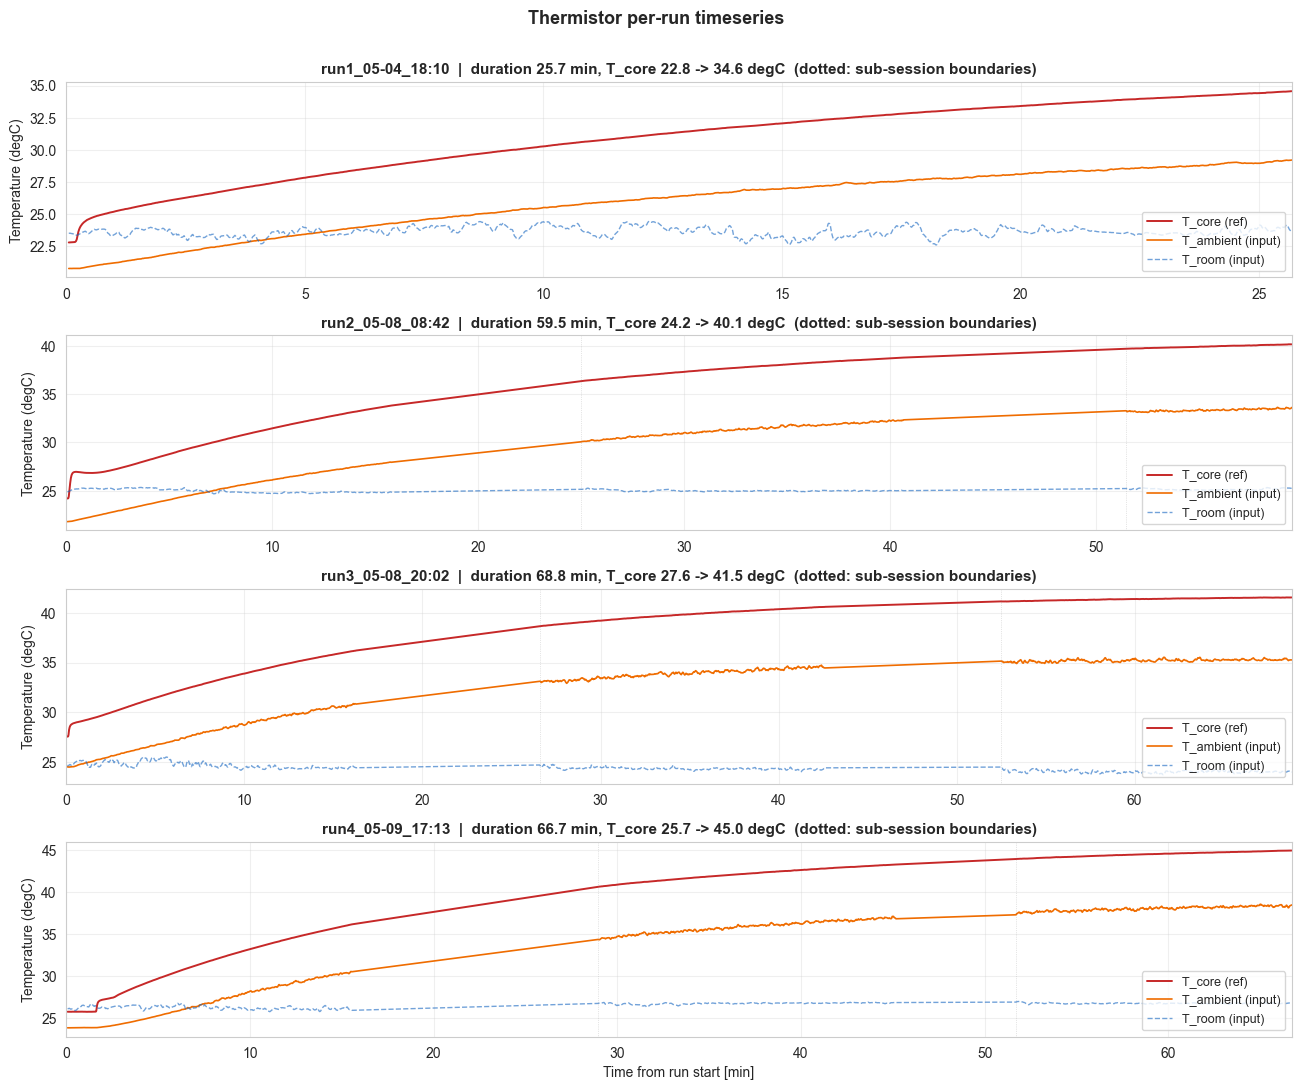

In [3]:
# Thermistor per-run timeseries (4 panels, sub-sessions concatenated within a run)
runs = sorted(df["run_label"].unique())

fig, axes = plt.subplots(len(runs), 1, figsize=(13, 2.7*len(runs)), sharey=False)
if len(runs) == 1: axes = [axes]

for ax, run_lbl in zip(axes, runs):
    g = df[df["run_label"] == run_lbl].sort_values("t_sec")
    t_min = g["t_sec"] / 60
    ax.plot(t_min, g["T_core"],    color=RED,    linewidth=1.4, label="T_core (ref)")
    ax.plot(t_min, g["T_ambient"], color=ORANGE, linewidth=1.2, label="T_ambient (input)")
    ax.plot(t_min, g["T_room"],    color=BLUE,   linewidth=1, alpha=0.6, linestyle="--", label="T_room (input)")
    for sub in g["sub_session"].unique()[1:]:
        b = g[g["sub_session"] == sub]["t_sec"].iloc[0] / 60
        ax.axvline(b, color="gray", linewidth=0.5, alpha=0.4, linestyle=":")
    ax.set_xlim(0, t_min.max())
    ax.set_ylabel("Temperature (degC)")
    ax.set_title(f"{run_lbl}  |  duration {t_min.max():.1f} min, "
                 f"T_core {g['T_core'].min():.1f} -> {g['T_core'].max():.1f} degC  "
                 f"(dotted: sub-session boundaries)", fontsize=11, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time from run start [min]")
plt.suptitle("Thermistor per-run timeseries", fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_timeseries_thermistor.png", dpi=150, bbox_inches="tight")
plt.show()


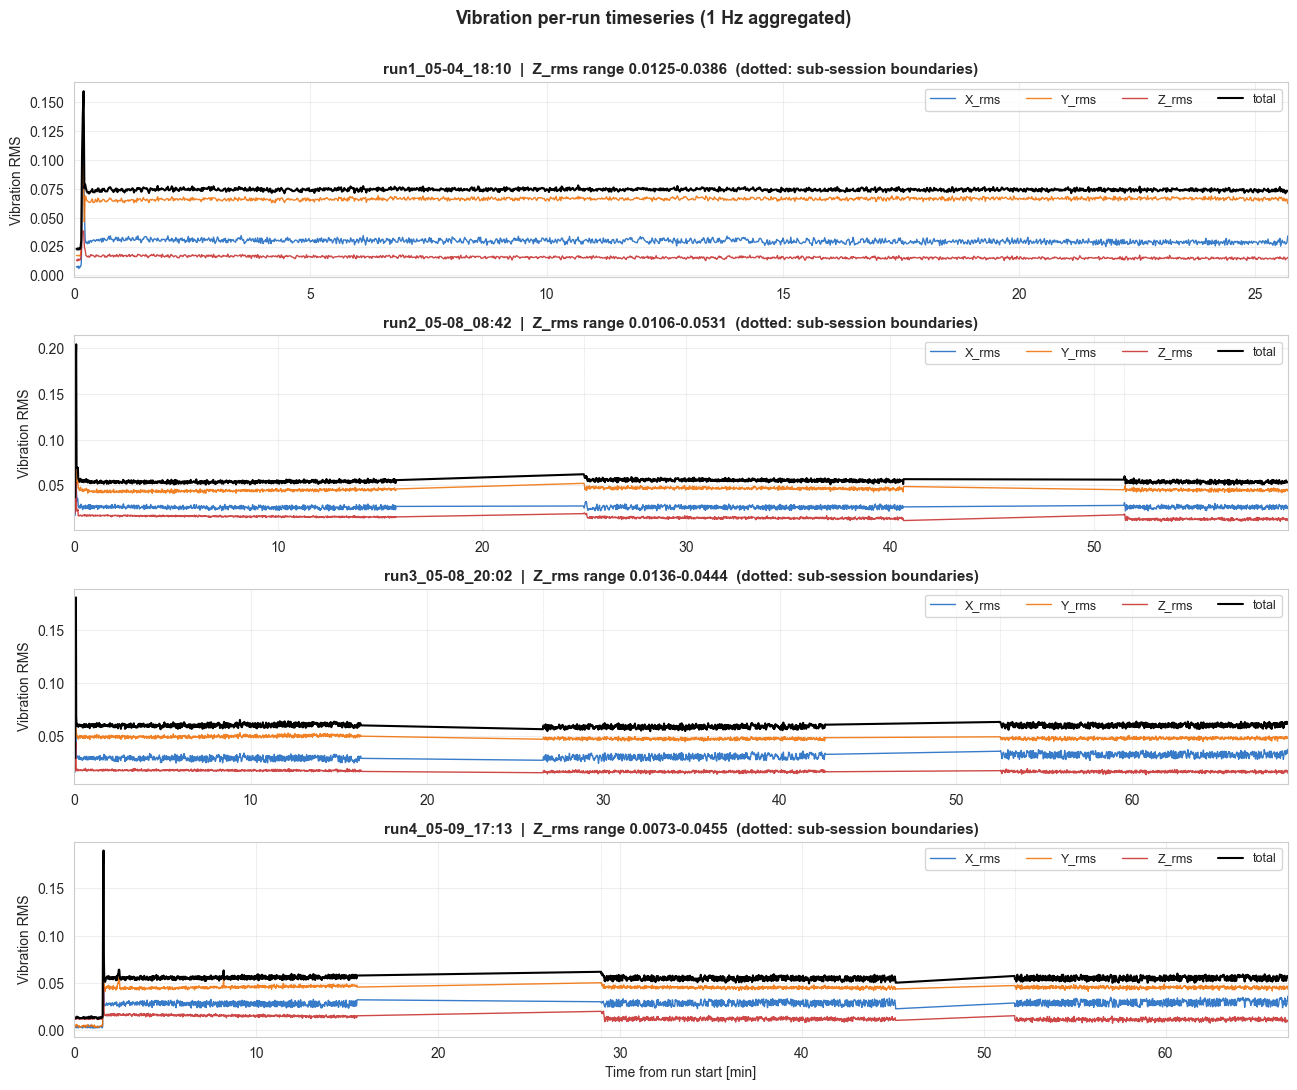

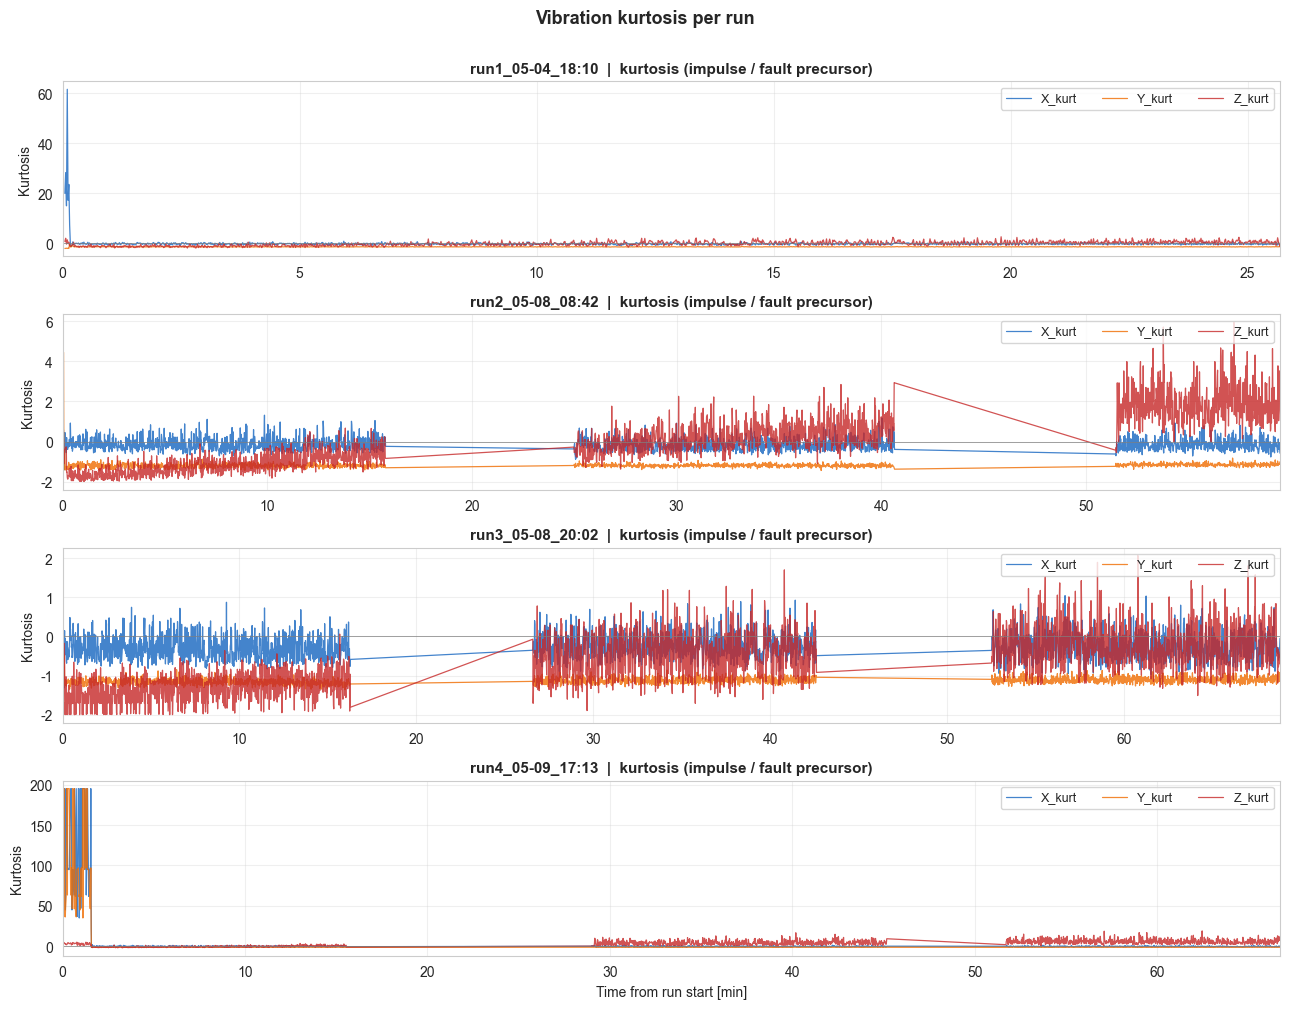

In [4]:
# Vibration per-run timeseries (4 panels, mirroring thermistor layout)
fig, axes = plt.subplots(len(runs), 1, figsize=(13, 2.7*len(runs)), sharey=False)
if len(runs) == 1: axes = [axes]

for ax, run_lbl in zip(axes, runs):
    g = df[df["run_label"] == run_lbl].sort_values("t_sec")
    t_min = g["t_sec"] / 60
    ax.plot(t_min, g["X_rms"],     color=BLUE,   linewidth=1.0, alpha=0.85, label="X_rms")
    ax.plot(t_min, g["Y_rms"],     color=ORANGE, linewidth=1.0, alpha=0.85, label="Y_rms")
    ax.plot(t_min, g["Z_rms"],     color=RED,    linewidth=1.0, alpha=0.85, label="Z_rms")
    ax.plot(t_min, g["rms_total"], color="black", linewidth=1.5, label="total")
    for sub in g["sub_session"].unique()[1:]:
        b = g[g["sub_session"] == sub]["t_sec"].iloc[0] / 60
        ax.axvline(b, color="gray", linewidth=0.5, alpha=0.4, linestyle=":")
    ax.set_xlim(0, t_min.max())
    ax.set_ylabel("Vibration RMS")
    ax.set_title(f"{run_lbl}  |  Z_rms range {g['Z_rms'].min():.4f}-{g['Z_rms'].max():.4f}  "
                 f"(dotted: sub-session boundaries)", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9, ncol=4)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time from run start [min]")
plt.suptitle("Vibration per-run timeseries (1 Hz aggregated)", fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_timeseries_vibration.png", dpi=150, bbox_inches="tight")
plt.show()

# Companion: kurtosis/crest per run (impulsive-event indicators)
fig, axes = plt.subplots(len(runs), 1, figsize=(13, 2.5*len(runs)), sharey=False)
if len(runs) == 1: axes = [axes]
for ax, run_lbl in zip(axes, runs):
    g = df[df["run_label"] == run_lbl].sort_values("t_sec")
    t_min = g["t_sec"] / 60
    ax.plot(t_min, g["X_kurt"], color=BLUE,   linewidth=0.9, alpha=0.8, label="X_kurt")
    ax.plot(t_min, g["Y_kurt"], color=ORANGE, linewidth=0.9, alpha=0.8, label="Y_kurt")
    ax.plot(t_min, g["Z_kurt"], color=RED,    linewidth=0.9, alpha=0.8, label="Z_kurt")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlim(0, t_min.max())
    ax.set_ylabel("Kurtosis")
    ax.set_title(f"{run_lbl}  |  kurtosis (impulse / fault precursor)", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9, ncol=3)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time from run start [min]")
plt.suptitle("Vibration kurtosis per run", fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_timeseries_vibration_kurt.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 2.5: EDA-driven feature pruning

Reduce 21 candidates → ~10 features using:
1. Definitional collinearity (drop derived totals)
2. High collinearity pairs (|r| > 0.95) — keep simpler / more direct one
3. Low target correlation (|r| < 0.15) — drop unless physics-justified
4. Domain-safety override — keep `dT_ambient_dt` even if weak in current data (transient detection for fire scenarios)

The result is stored in `FEATURE_COLS`. All sections below use this pruned list automatically.

In [5]:
# Variance + collinearity + target-correlation analysis
print("="*100)
print("(A) Feature variance — low-variance features carry little information")
print("="*100)
print(f"{'feature':<20} {'mean':>10} {'std':>10} {'CV':>10}")
print("-"*100)
for f in ALL_CANDIDATES:
    s = df[f]
    cv = s.std()/abs(s.mean()) if abs(s.mean()) > 1e-6 else float("inf")
    flag = "  low CV" if cv < 0.05 else ""
    print(f"{f:<20} {s.mean():>10.4f} {s.std():>10.4f} {cv:>10.4f}{flag}")

print()
print("="*100)
print(f"(B) High-collinearity pairs (|r| > 0.95) on PRIMARY_TARGET={PRIMARY_TARGET}")
print("="*100)
corr = df[ALL_CANDIDATES + [PRIMARY_TARGET]].corr()
collinear_pairs = []
for i, a in enumerate(ALL_CANDIDATES):
    for j, b in enumerate(ALL_CANDIDATES):
        if i < j and abs(corr.loc[a, b]) > 0.95:
            collinear_pairs.append((abs(corr.loc[a, b]), a, b, corr.loc[a, b]))
collinear_pairs.sort(reverse=True)
for v, a, b, signed in collinear_pairs:
    print(f"  {a:<20} <-> {b:<20}  r = {signed:+.4f}")

print()
print("="*100)
print(f"(C) Target ({PRIMARY_TARGET}) correlation ranking")
print("="*100)
tcorr_signed = corr[PRIMARY_TARGET].drop(PRIMARY_TARGET)
tcorr_abs = tcorr_signed.abs().sort_values(ascending=False)
for f in tcorr_abs.index:
    v = tcorr_signed[f]
    bar = "#" * int(abs(v) * 30)
    flag = "  weak" if abs(v) < 0.15 else ""
    print(f"  {f:<20}  r = {v:+.4f}  {bar}{flag}")

# ─── Automatic pruning ─────────────────────────
print()
print("="*100)
print("(D) Pruning decisions")
print("="*100)
to_drop = set()

# Definitional collinearity (totals)
for f in ["rms_total", "peak_total"]:
    if f in ALL_CANDIDATES:
        to_drop.add(f)
        print(f"  drop {f:<20} -- derived from per-axis (definitional)")

# High-collinearity pairs (>0.95): drop one, keeping the simpler/direct one
KEEP_PRIORITY = {"T_ambient", "T_room", "dT_ambient_dt", "delta_amb_room",
                 "t_sec", "X_rms", "Y_rms", "Z_rms", "X_kurt", "Z_kurt"}
for v, a, b, signed in collinear_pairs:
    if a in to_drop or b in to_drop: continue
    if a in KEEP_PRIORITY and b not in KEEP_PRIORITY:
        to_drop.add(b); print(f"  drop {b:<20} (collinear with kept {a}, r={signed:+.3f})")
    elif b in KEEP_PRIORITY and a not in KEEP_PRIORITY:
        to_drop.add(a); print(f"  drop {a:<20} (collinear with kept {b}, r={signed:+.3f})")
    else:
        weak = a if abs(tcorr_signed[a]) < abs(tcorr_signed[b]) else b
        kept = b if weak == a else a
        to_drop.add(weak); print(f"  drop {weak:<20} (collinear, weaker target corr; kept {kept})")

# Low target correlation (|r| < 0.15)
for f in ALL_CANDIDATES:
    if f in to_drop: continue
    if abs(tcorr_signed[f]) < 0.15:
        to_drop.add(f); print(f"  drop {f:<20} (low target corr, |r|={abs(tcorr_signed[f]):.3f})")

# ─── Domain-safety override ────────────────────
DOMAIN_SAFETY_KEEPS = ["dT_ambient_dt"]   # transient-rate signal — needed for fire-prevention extension
for f in DOMAIN_SAFETY_KEEPS:
    if f in to_drop:
        to_drop.discard(f)
        print(f"  KEEP {f:<20} (domain-safety override: rate signal critical for transient/fire detection)")

# ─── Final feature list ───────────────────────
FEATURE_COLS = [f for f in ALL_CANDIDATES if f not in to_drop]

print()
print("="*100)
print(f"FINAL FEATURE_COLS  ({len(FEATURE_COLS)} features)")
print("="*100)
for f in FEATURE_COLS:
    src = "thermistor" if f in THERM_FEATURES else "vibration"
    print(f"  + {f:<20} ({src})")
print(f"\nDropped: {len(to_drop)} features")

# Predict Poly(2)+LR size
n = len(FEATURE_COLS)
poly_terms = n + n + n*(n-1)//2 + 1
print(f"\nPoly(2)+LR with {n} features:")
print(f"  poly terms        = {poly_terms}")
print(f"  float32 weights   = {poly_terms*4} B (~{poly_terms*4/1024:.2f} KB)")
print(f"  + StandardScaler  = {n*2*4} B")
print(f"  total deployment  = {(poly_terms + n*2)*4} B")


(A) Feature variance — low-variance features carry little information
feature                    mean        std         CV
----------------------------------------------------------------------------------------------------
T_ambient               30.9361     4.7013     0.1520
T_room                  25.0493     1.1050     0.0441  low CV
dT_ambient_dt            0.0038     0.0178     4.7134
delta_amb_room           5.8868     4.3592     0.7405
T_ambient_ema           30.9024     4.7217     0.1528
T_amb_integral        8506.5912  9804.9007     1.1526
t_sec                 1765.7802  1244.6750     0.7049
X_rms                    0.0287     0.0048     0.1685
Y_rms                    0.0495     0.0084     0.1705
Z_rms                    0.0150     0.0024     0.1610
rms_total                0.0594     0.0087     0.1461
X_peak                   0.0742     0.0169     0.2274
Y_peak                   0.1016     0.0149     0.1471
Z_peak                   0.0405     0.0077     0.1893
peak_total 

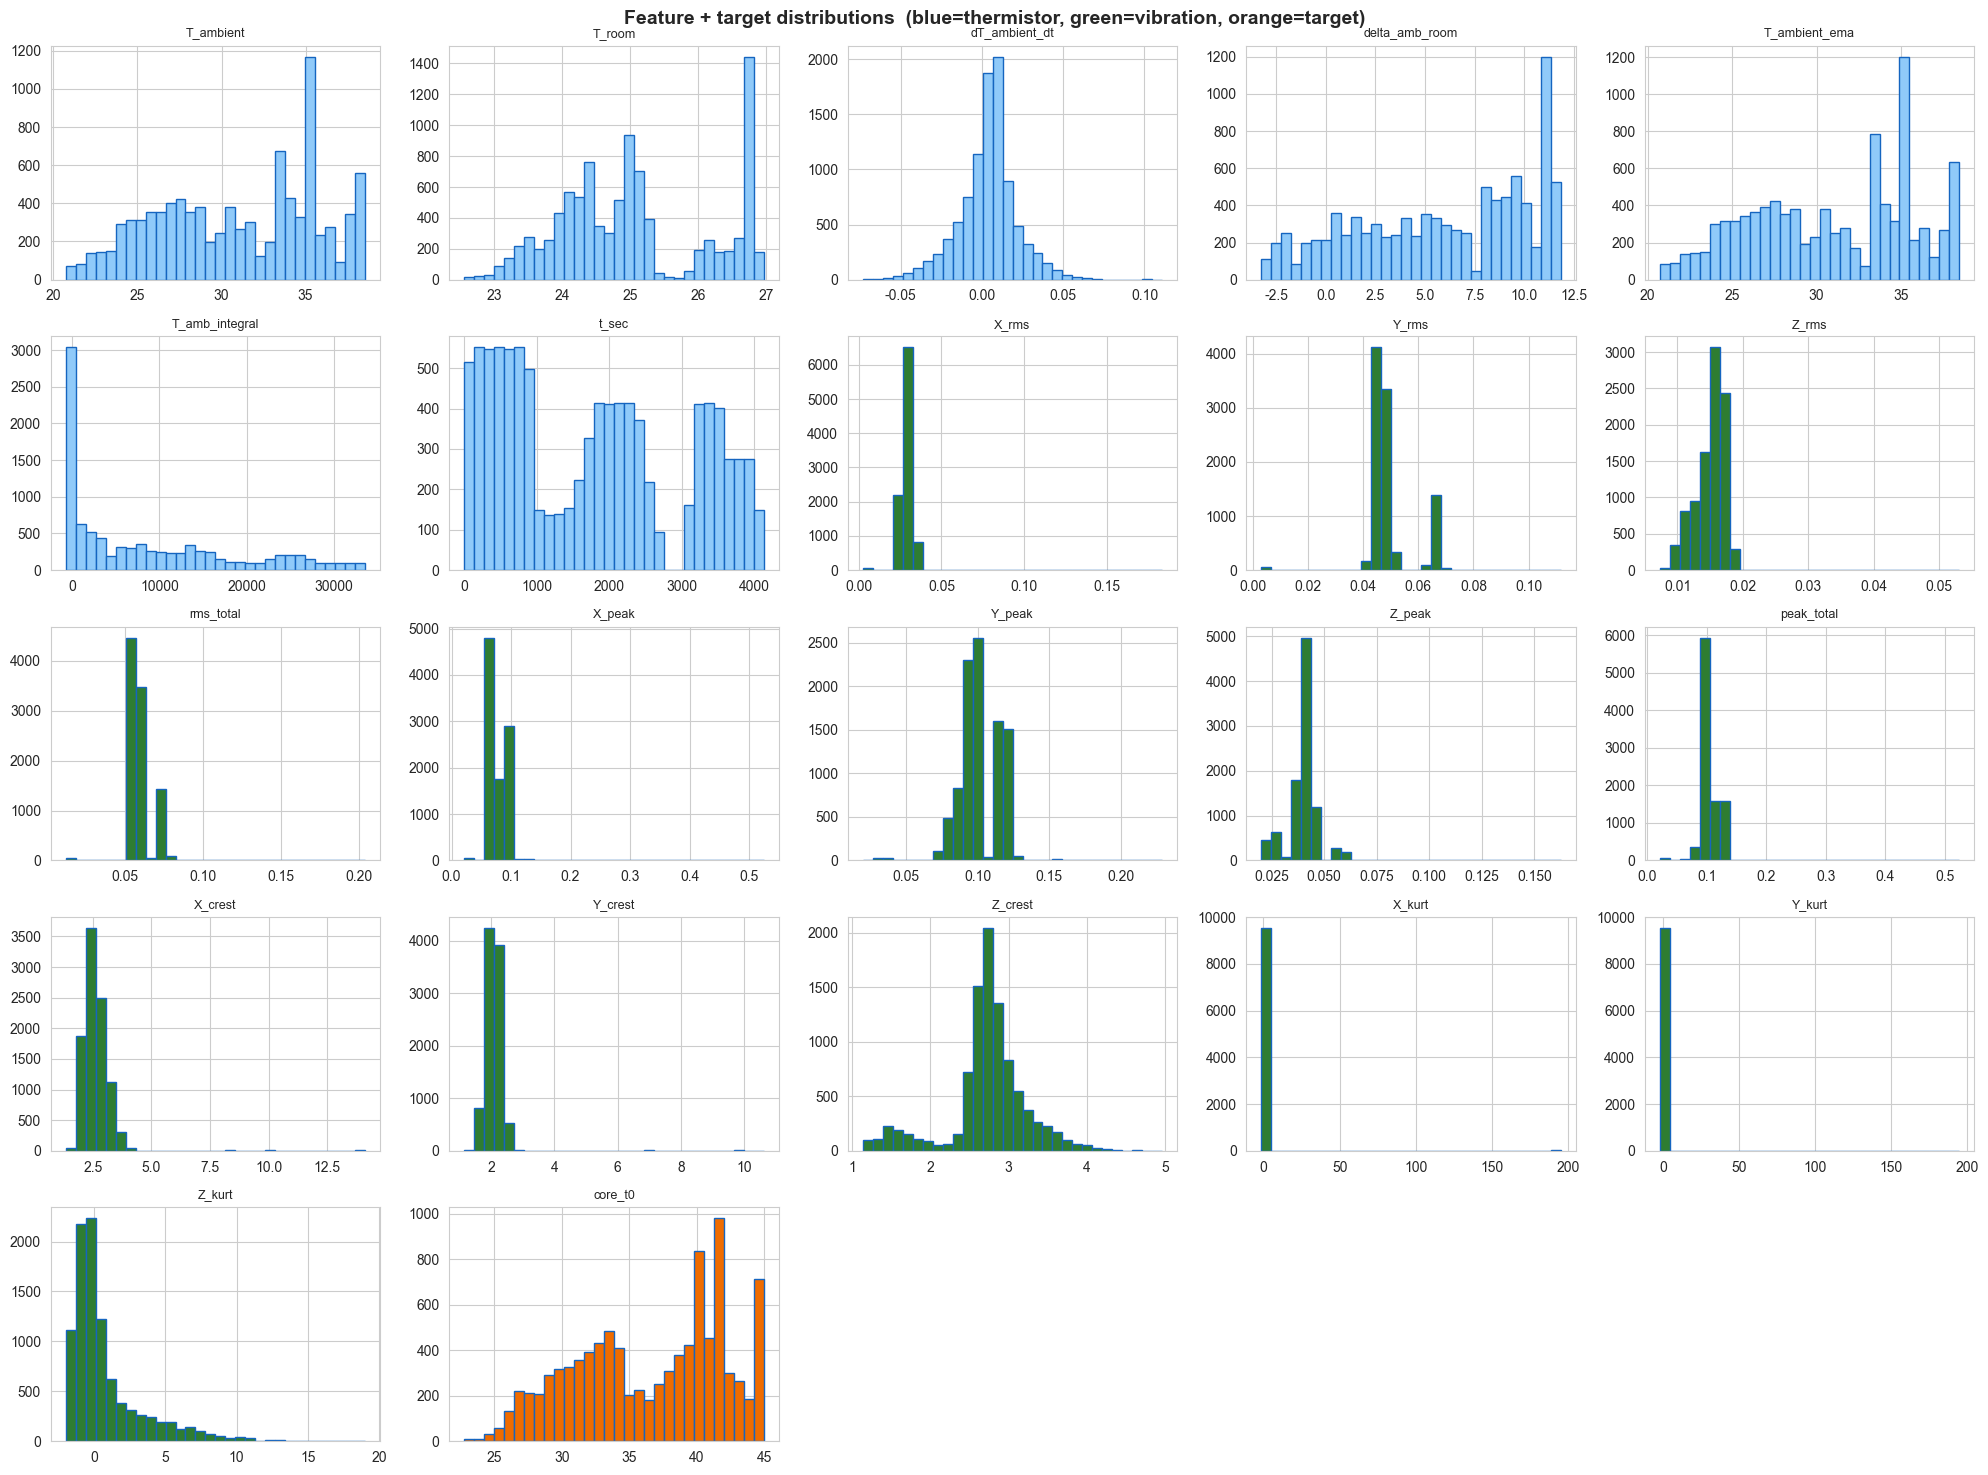

In [6]:
# Distribution histograms — full 21 candidates + primary target
all_cols = ALL_CANDIDATES + [PRIMARY_TARGET]
n_cols = 5
n_rows = (len(all_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    color = ORANGE if col == PRIMARY_TARGET else (
        GREEN if col in VIB_FEATURES else BLUE_LIGHT
    )
    axes[i].hist(df[col], bins=30, color=color, edgecolor=BLUE)
    axes[i].set_title(col, fontsize=9)

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature + target distributions  "
             "(blue=thermistor, green=vibration, orange=target)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


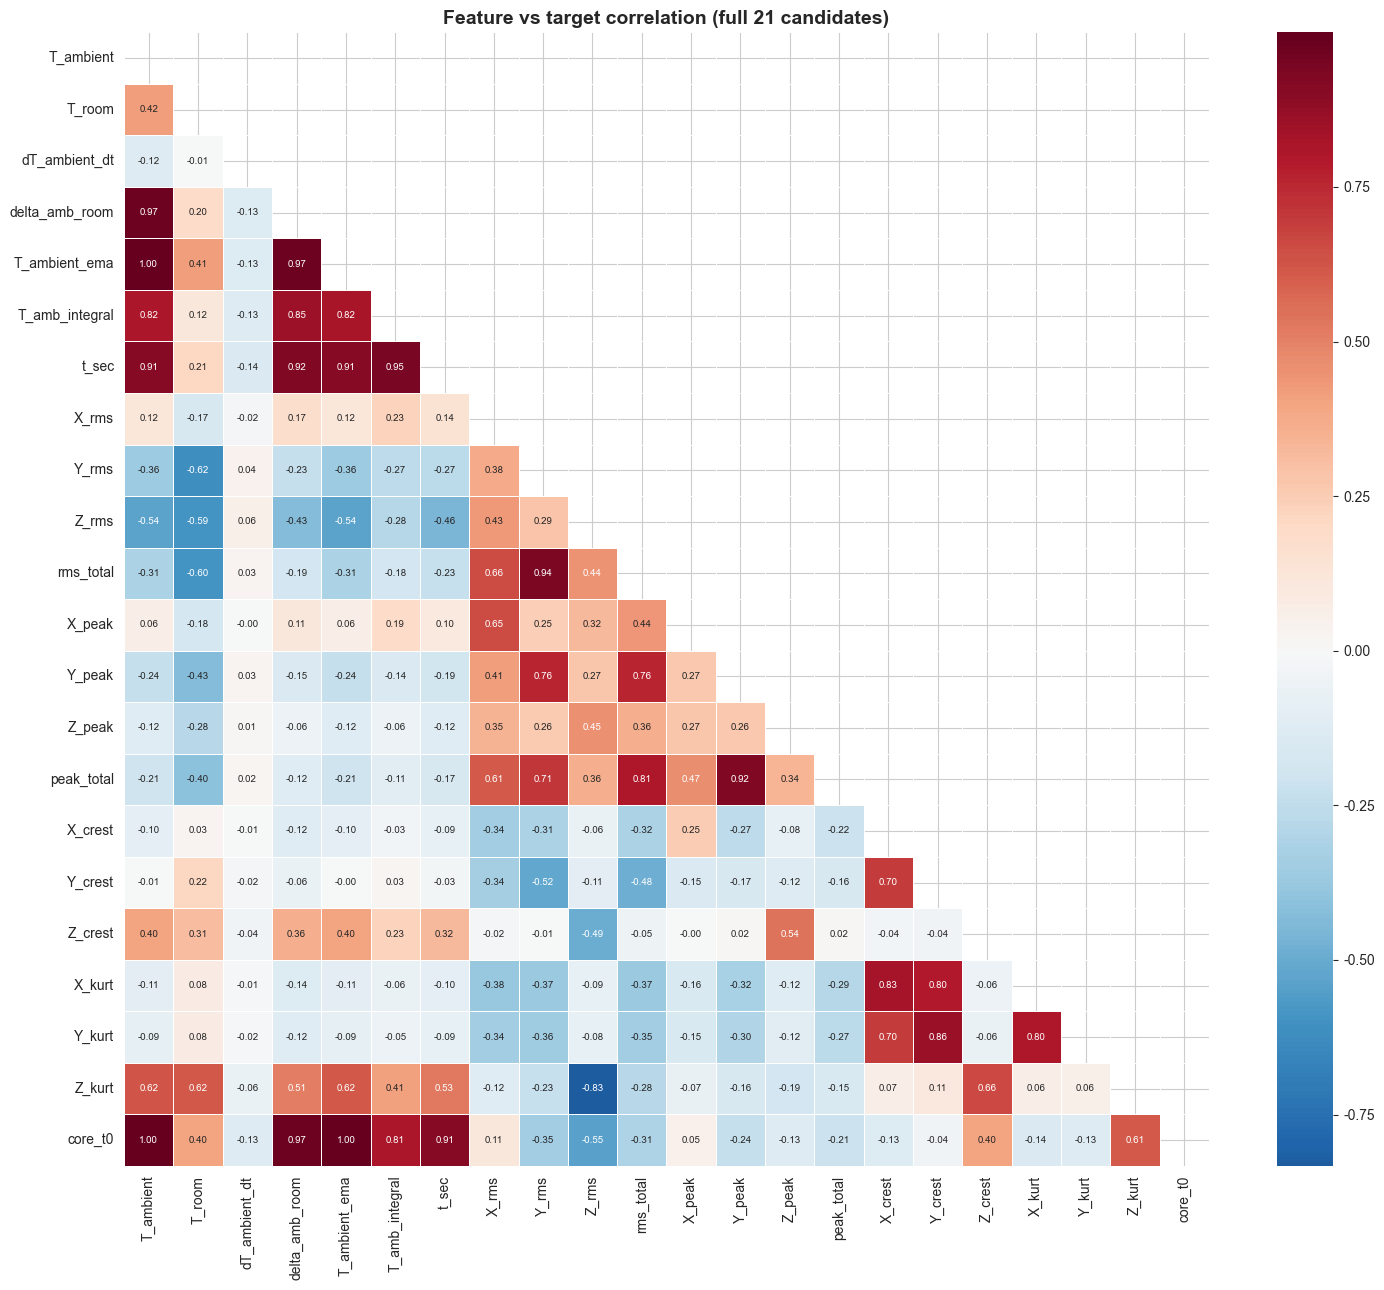

In [7]:
# Correlation heatmap — features vs target
fig, ax = plt.subplots(figsize=(15, 13))
corr = df[ALL_CANDIDATES + [PRIMARY_TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Feature vs target correlation (full 21 candidates)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


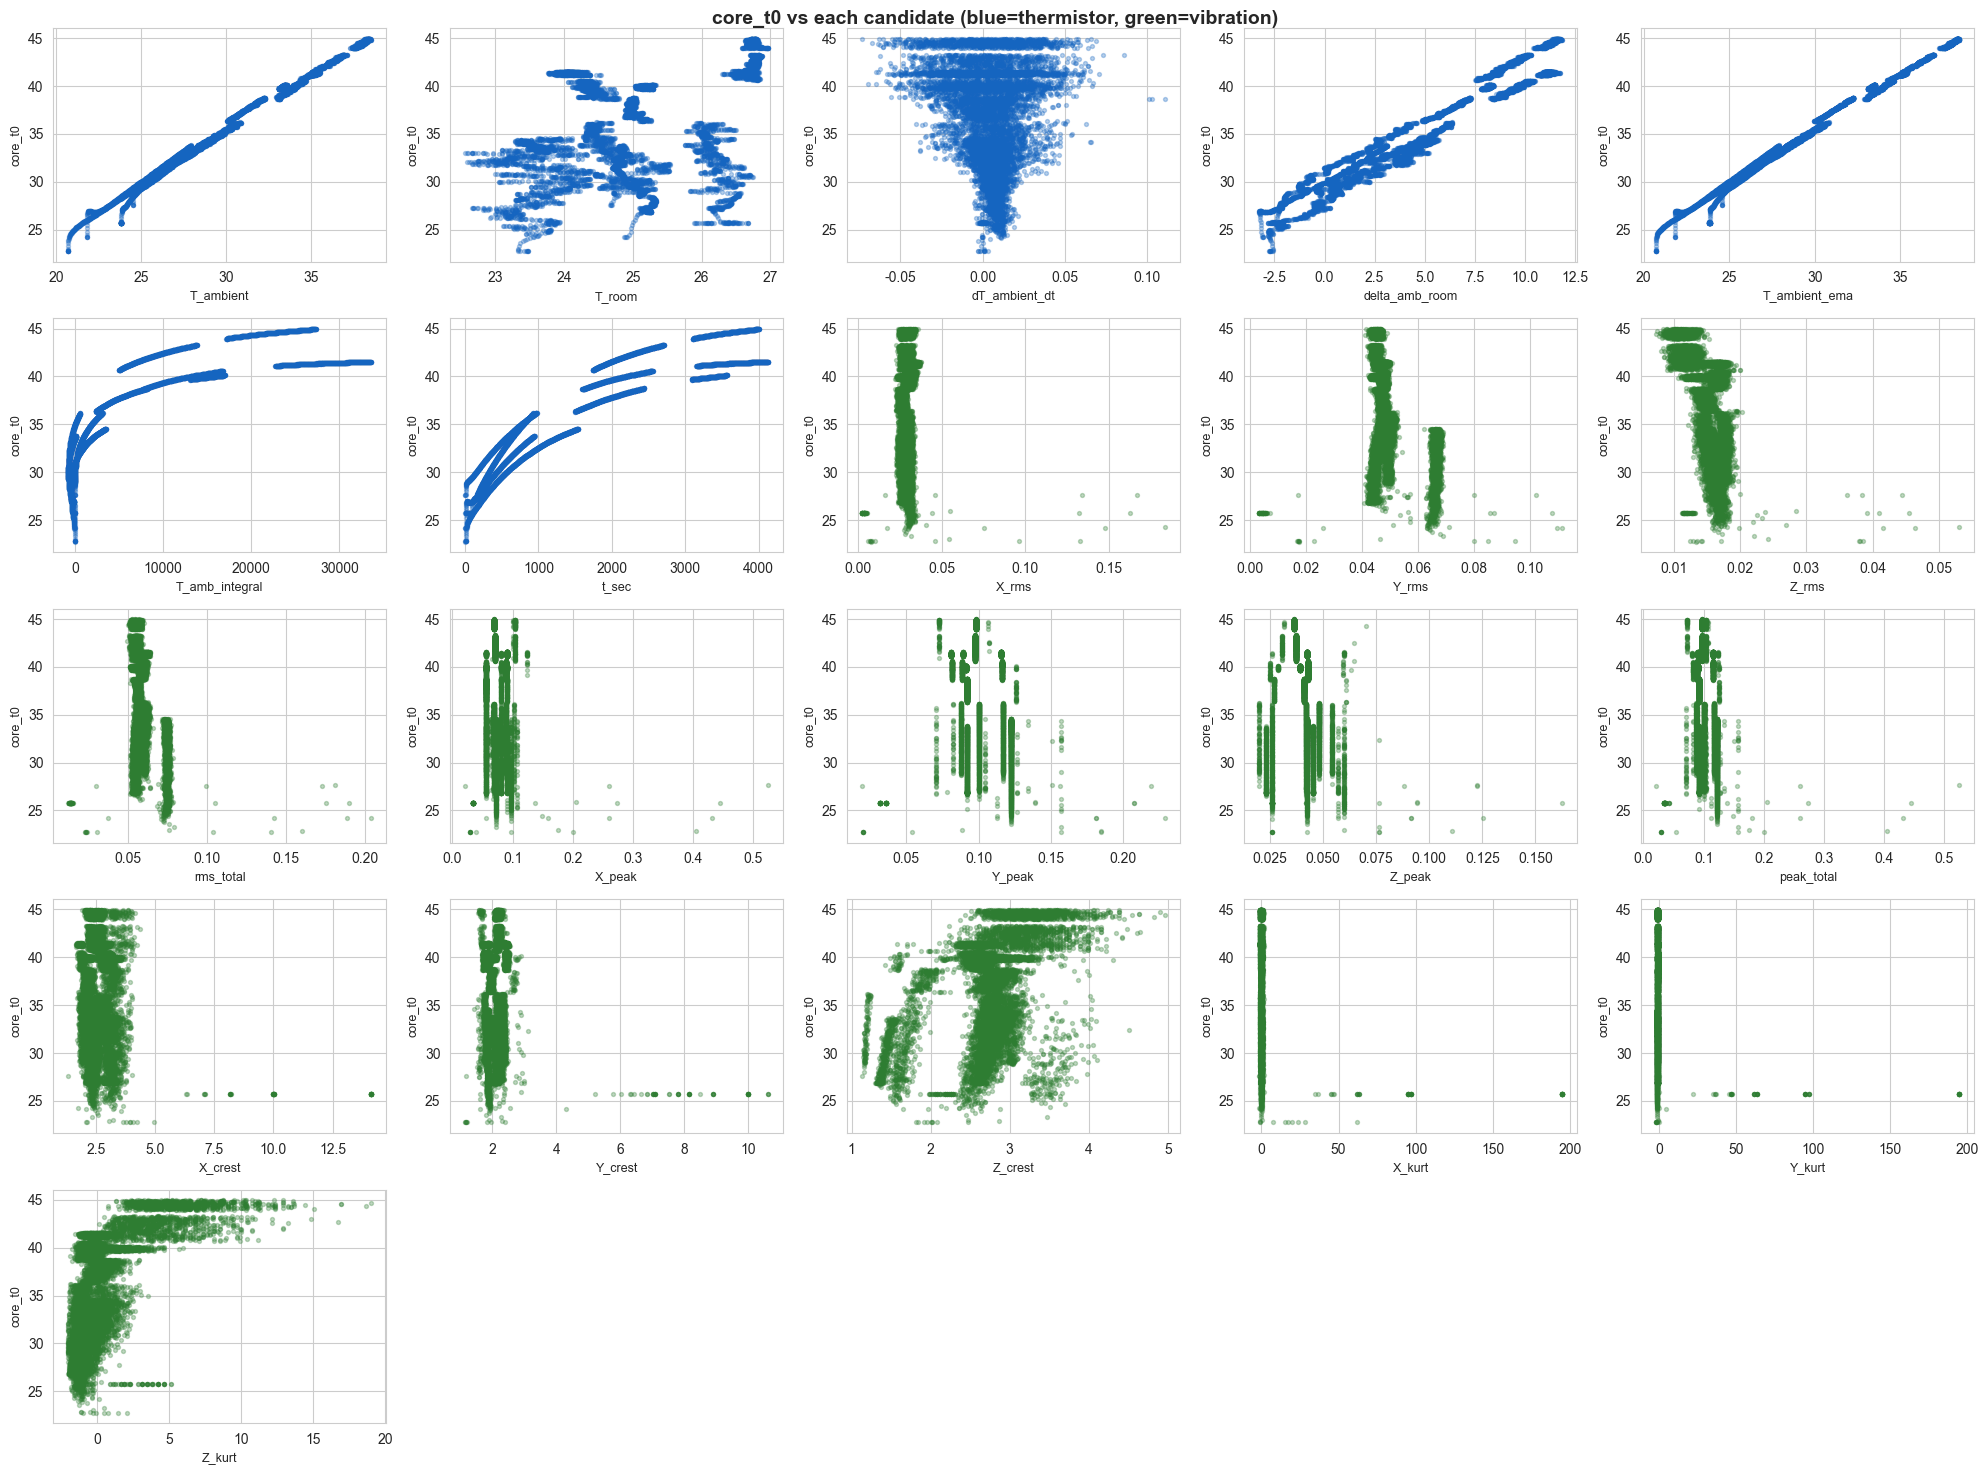

In [8]:
# Scatter: PRIMARY_TARGET vs each candidate feature
n_cols = 5
n_rows = (len(ALL_CANDIDATES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(ALL_CANDIDATES):
    color = GREEN if col in VIB_FEATURES else BLUE
    axes[i].scatter(df[col], df[PRIMARY_TARGET], alpha=0.3, s=8, color=color)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel(PRIMARY_TARGET, fontsize=9)

for j in range(len(ALL_CANDIDATES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"{PRIMARY_TARGET} vs each candidate (blue=thermistor, green=vibration)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_scatter_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 3: Preprocessing

In [9]:
# features는 호라이즌과 무관하게 동일 → 한 번만 split & scale
X_all = df[FEATURE_COLS].values
Y_all = {h: df[f"{TARGET_PREFIX}{h}"].values for h in HORIZONS}

# random split (시계열 leakage 우려 있으나 본 데이터는 정상상태 단일 운전 → 분포 동일)
# 추후 다양한 시나리오 추가되면 GroupKFold(by=run_id)로 전환 권장
idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

X_train = X_all[idx_train]
X_test  = X_all[idx_test]
y_train = {h: Y_all[h][idx_train] for h in HORIZONS}
y_test  = {h: Y_all[h][idx_test]  for h in HORIZONS}

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  Test: {X_test_sc.shape}")
for h in HORIZONS:
    yh = Y_all[h]
    print(f"  dT_core(t+{h:3d}s) range: [{yh.min():+.3f}, {yh.max():+.3f}] degC  (mean {yh.mean():+.3f})")


Train: (7674, 10)  Test: (1919, 10)
  dT_core(t+  0s) range: [+22.761, +44.958] degC  (mean +36.562)
  dT_core(t+ 30s) range: [+24.704, +44.972] degC  (mean +36.703)
  dT_core(t+ 60s) range: [+25.214, +44.990] degC  (mean +36.838)
  dT_core(t+120s) range: [+25.967, +45.027] degC  (mean +37.100)


## Section 4: PCA (SVD) Analysis

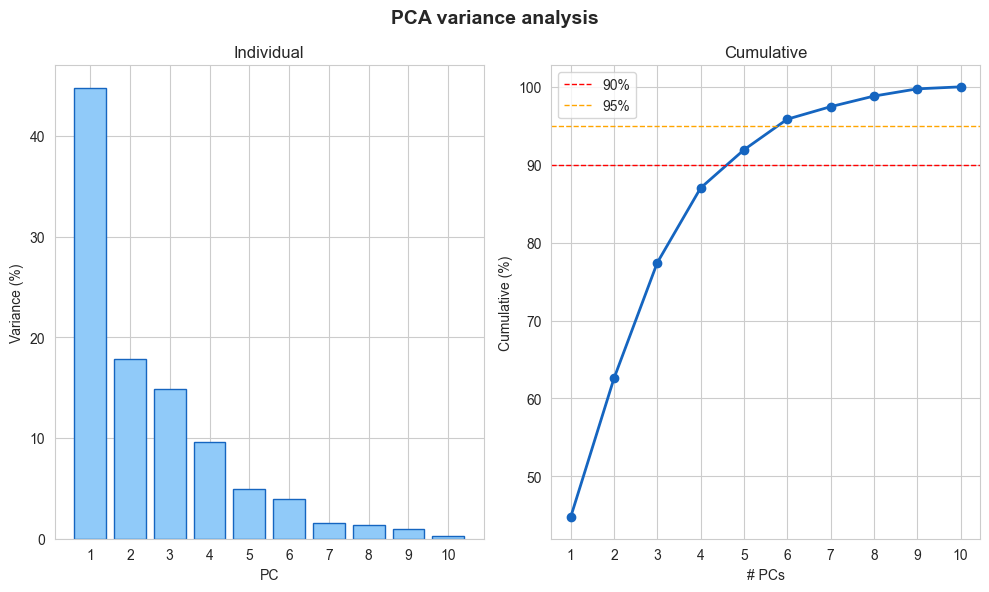

90%: 5 comps / 95%: 6 comps -> using 6 for SVD


In [10]:
pca_full = PCA(n_components=len(FEATURE_COLS))
pca_full.fit(X_train_sc)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].bar(range(1, len(explained)+1), explained * 100, color=BLUE_LIGHT, edgecolor=BLUE)
axes[0].set_xlabel("PC"); axes[0].set_ylabel("Variance (%)"); axes[0].set_title("Individual")
axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker="o", color=BLUE, linewidth=2)
axes[1].axhline(90, color="red",    linestyle="--", linewidth=1, label="90%")
axes[1].axhline(95, color="orange", linestyle="--", linewidth=1, label="95%")
axes[1].set_xlabel("# PCs"); axes[1].set_ylabel("Cumulative (%)"); axes[1].set_title("Cumulative")
axes[1].set_xticks(range(1, len(cumulative)+1)); axes[1].legend()

plt.suptitle("PCA variance analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

n_90 = int(np.searchsorted(cumulative, 0.90)) + 1
n_95 = int(np.searchsorted(cumulative, 0.95)) + 1
N_COMPONENTS = n_95
print(f"90%: {n_90} comps / 95%: {n_95} comps -> using {N_COMPONENTS} for SVD")


In [11]:
pca_table = pd.DataFrame({
    "# PCs": range(1, len(explained)+1),
    "Individual variance (%)": (explained * 100).round(2),
    "Cumulative (%)": (cumulative * 100).round(2),
}).set_index("# PCs")
pca_table


,Individual variance (%),Cumulative (%)
# PCs,,
1,44.75,44.75
2,17.82,62.57
3,14.86,77.43
4,9.59,87.02
5,4.90,91.91
6,3.93,95.85
7,1.61,97.45
8,1.36,98.81
9,0.93,99.74


## Section 5: Per-horizon Model Training and Comparison

In [12]:
def make_models():
    return {
        "Linear":              LinearRegression(),
        f"SVD({N_COMPONENTS})+LR": Pipeline([("pca", PCA(n_components=N_COMPONENTS)),
                                              ("lr",  LinearRegression())]),
        "Poly(2)+LR":          Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)),
                                         ("lr",   LinearRegression())]),
        "DT(d=5)":             DecisionTreeRegressor(max_depth=5, random_state=42),
        "XGB":                 XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                            random_state=42, verbosity=0),
    }

results_long = []         # 길게 펼친 결과 (호라이즌 × 모델)
predictions  = {}         # predictions[h][model_name] = y_pred

for h in HORIZONS:
    print(f"\n------ Horizon t+{h}s ------")
    predictions[h] = {}
    for name, model in make_models().items():
        model.fit(X_train_sc, y_train[h])
        y_pred = model.predict(X_test_sc)
        mae  = mean_absolute_error(y_test[h], y_pred)
        rmse = mean_squared_error(y_test[h], y_pred) ** 0.5
        r2   = r2_score(y_test[h], y_pred)
        print(f"  [{name:14s}] MAE={mae:.3f}  RMSE={rmse:.3f}  R^2={r2:.4f}")
        results_long.append({"horizon": h, "model": name,
                             "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R^2": round(r2, 4)})
        predictions[h][name] = y_pred

results_df = pd.DataFrame(results_long)
results_df.set_index(["horizon", "model"]).style.background_gradient(cmap="Blues", subset=["R^2"]).format(precision=4)



------ Horizon t+0s ------
  [Linear        ] MAE=0.180  RMSE=0.283  R^2=0.9973
  [SVD(6)+LR     ] MAE=1.393  RMSE=1.700  R^2=0.9043
  [Poly(2)+LR    ] MAE=0.079  RMSE=0.138  R^2=0.9994
  [DT(d=5)       ] MAE=0.209  RMSE=0.293  R^2=0.9972
  [XGB           ] MAE=0.044  RMSE=0.065  R^2=0.9999

------ Horizon t+30s ------
  [Linear        ] MAE=0.169  RMSE=0.260  R^2=0.9977
  [SVD(6)+LR     ] MAE=1.358  RMSE=1.652  R^2=0.9057
  [Poly(2)+LR    ] MAE=0.071  RMSE=0.116  R^2=0.9995
  [DT(d=5)       ] MAE=0.193  RMSE=0.260  R^2=0.9977
  [XGB           ] MAE=0.042  RMSE=0.061  R^2=0.9999

------ Horizon t+60s ------
  [Linear        ] MAE=0.160  RMSE=0.243  R^2=0.9979
  [SVD(6)+LR     ] MAE=1.325  RMSE=1.613  R^2=0.9068
  [Poly(2)+LR    ] MAE=0.067  RMSE=0.104  R^2=0.9996
  [DT(d=5)       ] MAE=0.191  RMSE=0.252  R^2=0.9977
  [XGB           ] MAE=0.039  RMSE=0.057  R^2=0.9999

------ Horizon t+120s ------
  [Linear        ] MAE=0.155  RMSE=0.220  R^2=0.9981
  [SVD(6)+LR     ] MAE=1.262  RMSE=1

## Section 6: 5-fold Cross-Validation (per horizon)

t+  0s [Linear        ] CV MAE = 0.173 +/- 0.002
t+  0s [SVD(6)+LR     ] CV MAE = 1.362 +/- 0.026
t+  0s [Poly(2)+LR    ] CV MAE = 0.078 +/- 0.001
t+  0s [DT(d=5)       ] CV MAE = 0.201 +/- 0.002
t+  0s [XGB           ] CV MAE = 0.047 +/- 0.002
t+ 30s [Linear        ] CV MAE = 0.163 +/- 0.003
t+ 30s [SVD(6)+LR     ] CV MAE = 1.328 +/- 0.028
t+ 30s [Poly(2)+LR    ] CV MAE = 0.072 +/- 0.002
t+ 30s [DT(d=5)       ] CV MAE = 0.190 +/- 0.002
t+ 30s [XGB           ] CV MAE = 0.044 +/- 0.001
t+ 60s [Linear        ] CV MAE = 0.156 +/- 0.003
t+ 60s [SVD(6)+LR     ] CV MAE = 1.296 +/- 0.026
t+ 60s [Poly(2)+LR    ] CV MAE = 0.068 +/- 0.001
t+ 60s [DT(d=5)       ] CV MAE = 0.185 +/- 0.002
t+ 60s [XGB           ] CV MAE = 0.043 +/- 0.001
t+120s [Linear        ] CV MAE = 0.150 +/- 0.003
t+120s [SVD(6)+LR     ] CV MAE = 1.233 +/- 0.025
t+120s [Poly(2)+LR    ] CV MAE = 0.061 +/- 0.001
t+120s [DT(d=5)       ] CV MAE = 0.198 +/- 0.004
t+120s [XGB           ] CV MAE = 0.040 +/- 0.001


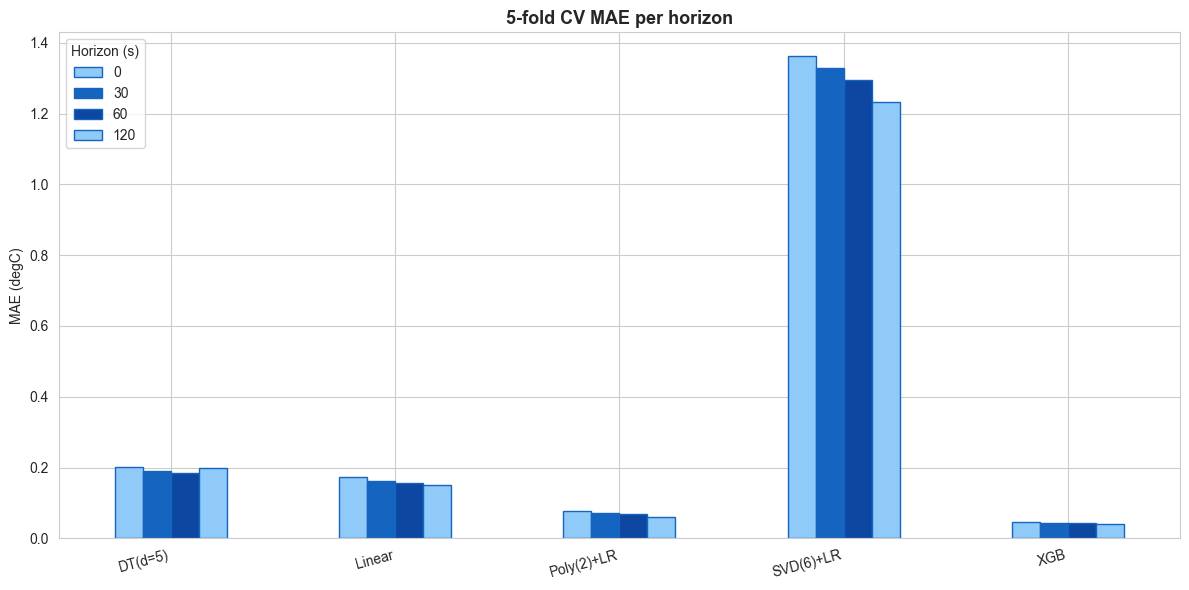

CV MAE mean  CV MAE std
horizon model                              
0       Linear           0.1730      0.0021
        SVD(6)+LR        1.3617      0.0262
        Poly(2)+LR       0.0776      0.0011
        DT(d=5)          0.2012      0.0022
        XGB              0.0473      0.0017
30      Linear           0.1633      0.0028
        SVD(6)+LR        1.3278      0.0277
        Poly(2)+LR       0.0717      0.0016
        DT(d=5)          0.1901      0.0018
        XGB              0.0445      0.0014
60      Linear           0.1563      0.0028
        SVD(6)+LR        1.2962      0.0263
        Poly(2)+LR       0.0685      0.0015
        DT(d=5)          0.1852      0.0021
        XGB              0.0427      0.0009
120     Linear           0.1498      0.0028
        SVD(6)+LR        1.2334      0.0250
        Poly(2)+LR       0.0614      0.0009
        DT(d=5)          0.1979      0.0045
        XGB              0.0402      0.0011

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_long = []

for h in HORIZONS:
    for name, model in make_models().items():
        scores = -cross_val_score(model, X_train_sc, y_train[h],
                                  cv=kf, scoring="neg_mean_absolute_error")
        cv_long.append({"horizon": h, "model": name,
                        "CV MAE mean": round(scores.mean(), 4),
                        "CV MAE std": round(scores.std(), 4)})
        print(f"t+{h:3d}s [{name:14s}] CV MAE = {scores.mean():.3f} +/- {scores.std():.3f}")

cv_df = pd.DataFrame(cv_long)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = cv_df.pivot(index="model", columns="horizon", values="CV MAE mean")
pivot.plot(kind="bar", ax=ax, color=[BLUE_LIGHT, BLUE, "#0D47A1"], edgecolor=BLUE)
ax.set_ylabel("MAE (degC)"); ax.set_xlabel("")
ax.set_title("5-fold CV MAE per horizon", fontsize=13, fontweight="bold")
ax.legend(title="Horizon (s)", loc="upper left")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_cv_mae.png", dpi=150, bbox_inches="tight")
plt.show()
cv_df.set_index(["horizon", "model"])


## Section 7: Final Model Visualization (primary horizon)

In [14]:
# 호라이즌별 최고 R^2 모델 자동 선택
best_per_h = (results_df.loc[results_df.groupby("horizon")["R^2"].idxmax()]
              [["horizon", "model", "MAE", "RMSE", "R^2"]]
              .reset_index(drop=True))
print("=== Best model per horizon ===")
print(best_per_h.to_string(index=False))
print()

BEST_MODEL_NAME = best_per_h.loc[best_per_h["horizon"] == PRIMARY_H, "model"].values[0]
y_pred_best = predictions[PRIMARY_H][BEST_MODEL_NAME]
y_true_best = y_test[PRIMARY_H]
residuals   = y_true_best - y_pred_best
print(f"Final model for primary horizon (t+{PRIMARY_H}s): {BEST_MODEL_NAME}")


=== Best model per horizon ===
 horizon model    MAE   RMSE    R^2
       0   XGB 0.0442 0.0650 0.9999
      30   XGB 0.0418 0.0614 0.9999
      60   XGB 0.0393 0.0567 0.9999
     120   XGB 0.0376 0.0539 0.9999

Final model for primary horizon (t+0s): XGB


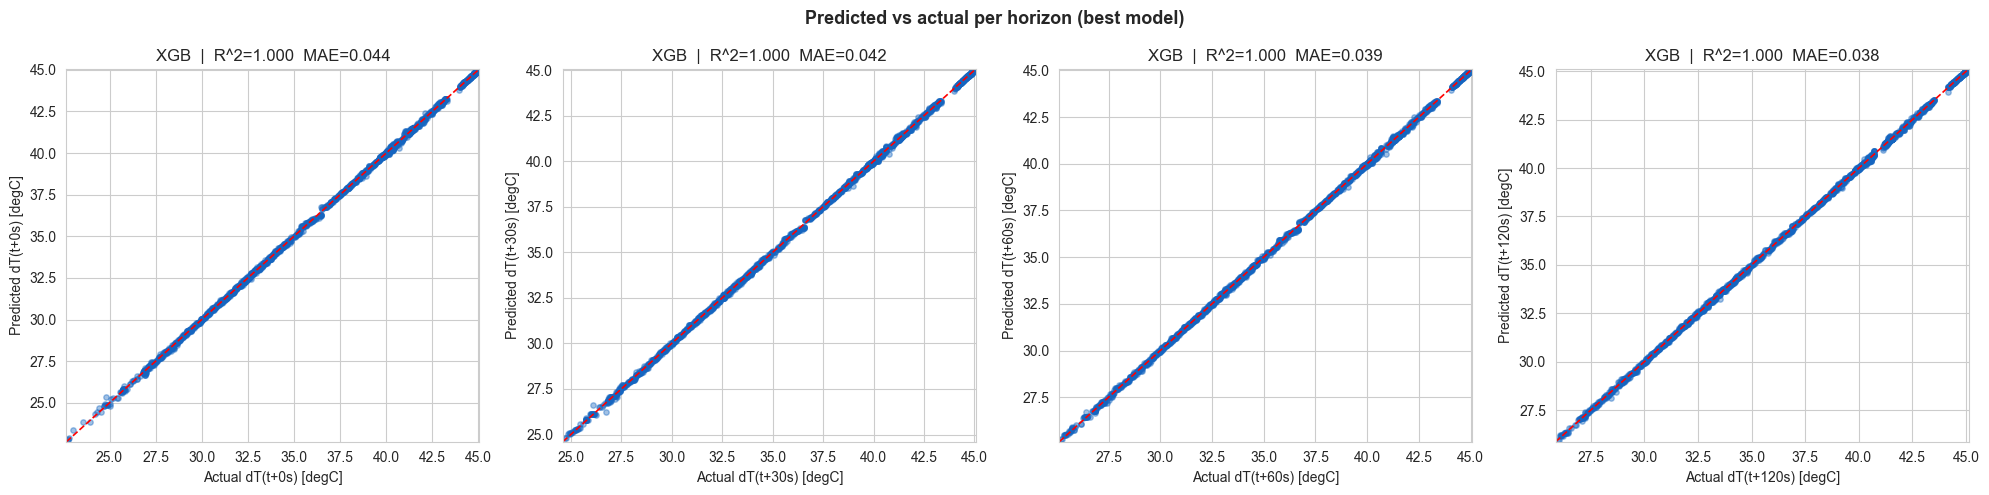

In [15]:
# 호라이즌 3개 동시 — Predicted vs Actual (best per horizon)
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5*len(HORIZONS), 5))
if len(HORIZONS) == 1:
    axes = [axes]

for i, h in enumerate(HORIZONS):
    best_name = best_per_h.loc[best_per_h["horizon"] == h, "model"].values[0]
    yp = predictions[h][best_name]
    yt = y_test[h]
    lo = min(yt.min(), yp.min()) - 0.1
    hi = max(yt.max(), yp.max()) + 0.1
    axes[i].scatter(yt, yp, alpha=0.4, s=15, color=BLUE)
    axes[i].plot([lo, hi], [lo, hi], "r--", linewidth=1.2)
    axes[i].set_xlim(lo, hi); axes[i].set_ylim(lo, hi)
    axes[i].set_xlabel(f"Actual dT(t+{h}s) [degC]")
    axes[i].set_ylabel(f"Predicted dT(t+{h}s) [degC]")
    r2 = r2_score(yt, yp)
    mae = mean_absolute_error(yt, yp)
    axes[i].set_title(f"{best_name}  |  R^2={r2:.3f}  MAE={mae:.3f}")

plt.suptitle("Predicted vs actual per horizon (best model)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


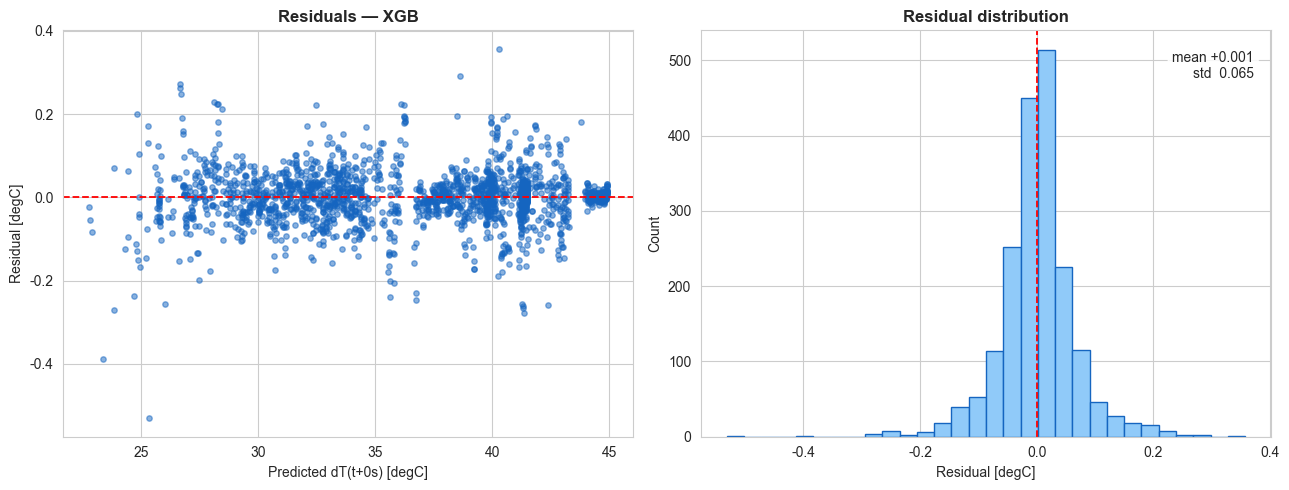

In [16]:
# Residual plot (대표 호라이즌)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.5, s=15, color=BLUE)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.3)
axes[0].set_xlabel(f"Predicted dT(t+{PRIMARY_H}s) [degC]"); axes[0].set_ylabel("Residual [degC]")
axes[0].set_title(f"Residuals — {BEST_MODEL_NAME}", fontweight="bold")

axes[1].hist(residuals, bins=30, color=BLUE_LIGHT, edgecolor=BLUE)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.3)
axes[1].set_xlabel("Residual [degC]"); axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution", fontweight="bold")
axes[1].text(0.97, 0.95, f"mean {residuals.mean():+.3f}\nstd  {residuals.std():.3f}",
             transform=axes[1].transAxes, ha="right", va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 8: Results Summary

=== Horizon x Model summary ===
                       MAE    RMSE     R^2  CV MAE mean  CV MAE std
horizon model                                                      
0       Linear      0.1802  0.2832  0.9973       0.1730      0.0021
        SVD(6)+LR   1.3926  1.6997  0.9043       1.3617      0.0262
        Poly(2)+LR  0.0786  0.1384  0.9994       0.0776      0.0011
        DT(d=5)     0.2089  0.2931  0.9972       0.2012      0.0022
        XGB         0.0442  0.0650  0.9999       0.0473      0.0017
30      Linear      0.1686  0.2604  0.9977       0.1633      0.0028
        SVD(6)+LR   1.3575  1.6524  0.9057       1.3278      0.0277
        Poly(2)+LR  0.0708  0.1159  0.9995       0.0717      0.0016
        DT(d=5)     0.1933  0.2598  0.9977       0.1901      0.0018
        XGB         0.0418  0.0614  0.9999       0.0445      0.0014
60      Linear      0.1605  0.2426  0.9979       0.1563      0.0028
        SVD(6)+LR   1.3254  1.6127  0.9068       1.2962      0.0263
        Poly(2)+

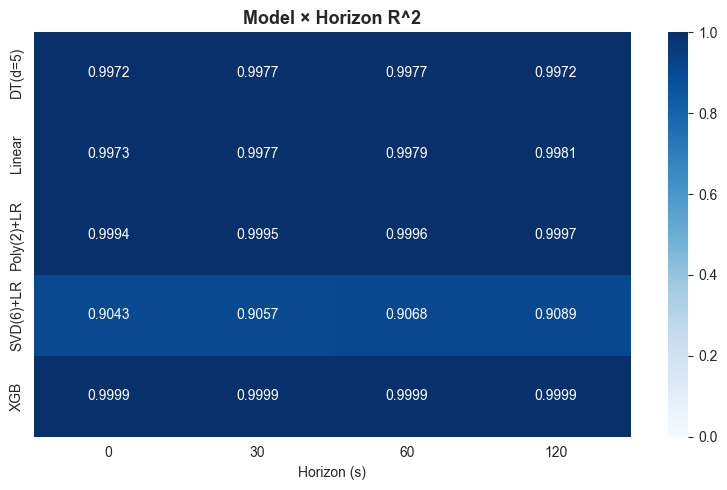

In [17]:
# 통합 요약: 테스트 + CV
summary = results_df.merge(cv_df, on=["horizon", "model"])
summary = summary.set_index(["horizon", "model"])
print("=== Horizon x Model summary ===")
print(summary.to_string())

# Model × Horizon R^2 히트맵
fig, ax = plt.subplots(figsize=(8, 5))
r2_pivot = results_df.pivot(index="model", columns="horizon", values="R^2")
sns.heatmap(r2_pivot, annot=True, fmt=".4f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Model × Horizon R^2", fontsize=13, fontweight="bold")
ax.set_xlabel("Horizon (s)"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_r2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


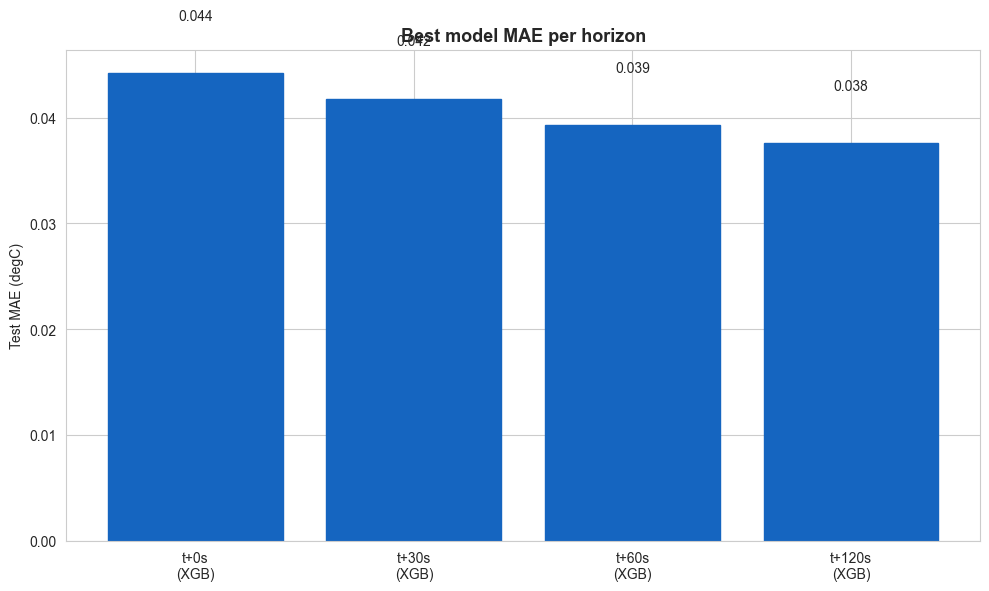


Saved figures:
  ../output/figures/.ipynb_checkpoints
  ../output/figures/00_timeseries.png
  ../output/figures/00_timeseries_thermistor.png
  ../output/figures/00_timeseries_vibration.png
  ../output/figures/00_timeseries_vibration_kurt.png
  ../output/figures/01_feature_distributions.png
  ../output/figures/02_correlation_heatmap.png
  ../output/figures/03_scatter_vs_target.png
  ../output/figures/04_pca_variance.png
  ../output/figures/05_cv_mae.png
  ../output/figures/06_pred_vs_actual.png
  ../output/figures/07_residual_plot.png
  ../output/figures/07_residuals.png
  ../output/figures/08_r2_heatmap.png
  ../output/figures/08_residual_hist.png
  ../output/figures/09_best_mae_per_horizon.png
  ../output/figures/09_model_comparison.png
  ../output/figures/10_r2_comparison.png
  ../output/figures/10_ttt_extrapolation.png
  ../output/figures/11_model_size_comparison.png
  ../output/figures/12_vibration_features.png
  ../output/figures/13_vibration_validation.png


In [18]:
# MAE 비교 — 호라이즌별 최고 모델만
fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(HORIZONS))
mae_test = [best_per_h.loc[best_per_h["horizon"]==h, "MAE"].values[0] for h in HORIZONS]
labels   = [f"t+{h}s\n({best_per_h.loc[best_per_h['horizon']==h, 'model'].values[0]})" for h in HORIZONS]
bars = ax.bar(x, mae_test, color=BLUE, edgecolor=BLUE)
for b, v in zip(bars, mae_test):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Test MAE (degC)")
ax.set_title("Best model MAE per horizon", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_best_mae_per_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved figures:")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  {FIGURES_DIR}/{f}")


In [19]:
# 대표 호라이즌(60s) 최종 결과 출력
best_row = summary.loc[(PRIMARY_H, BEST_MODEL_NAME)]
print("=" * 50)
print(f"Primary horizon: t + {PRIMARY_H}s")
print(f"Final model: {BEST_MODEL_NAME}")
print(f" Test MAE : "
      f"{best_row['MAE']:.3f} degC")
print(f"  Test RMSE : "
      f"{best_row['RMSE']:.3f} degC")
    
print(f"  Test R^2  : "
      f" {best_row['R^2']:.4f}")
print(f"  CV MAE    : "
      f" {best_row['CV MAE mean']:.3f} +/- {best_row['CV MAE std']:.3f} degC")
print("=" * 50)
print("\nNext: Section 9 (TTT) or python ../scripts/export_to_c.py")


Primary horizon: t + 0s
Final model: XGB
 Test MAE : 0.044 degC
  Test RMSE : 0.065 degC
  Test R^2  :  0.9999
  CV MAE    :  0.047 +/- 0.002 degC

Next: Section 9 (TTT) or python ../scripts/export_to_c.py


## Section 9: Time-To-Threshold (TTT) Analysis

**목적:** 임계온도 `T_crit` 가 정해지면, 현재 상태에서 **몇 초 뒤 도달**하는지 추정.
**전략:** 학습된 호라이즌 모델로 예측한 ΔT 추세를 선형 외삽 → `TTT ≈ (T_crit − T_core) / (ΔT_predicted / horizon)`

데이터에 임계 도달 사례가 없으므로 (현재 max 38.8°C) 본 셀은 **모델이 추세를 어떻게 외삽하는지**를 보여주는 진단용입니다. 실제 임계 데이터가 추가되면 다이렉트 TTT 회귀 모델로 교체 권장.

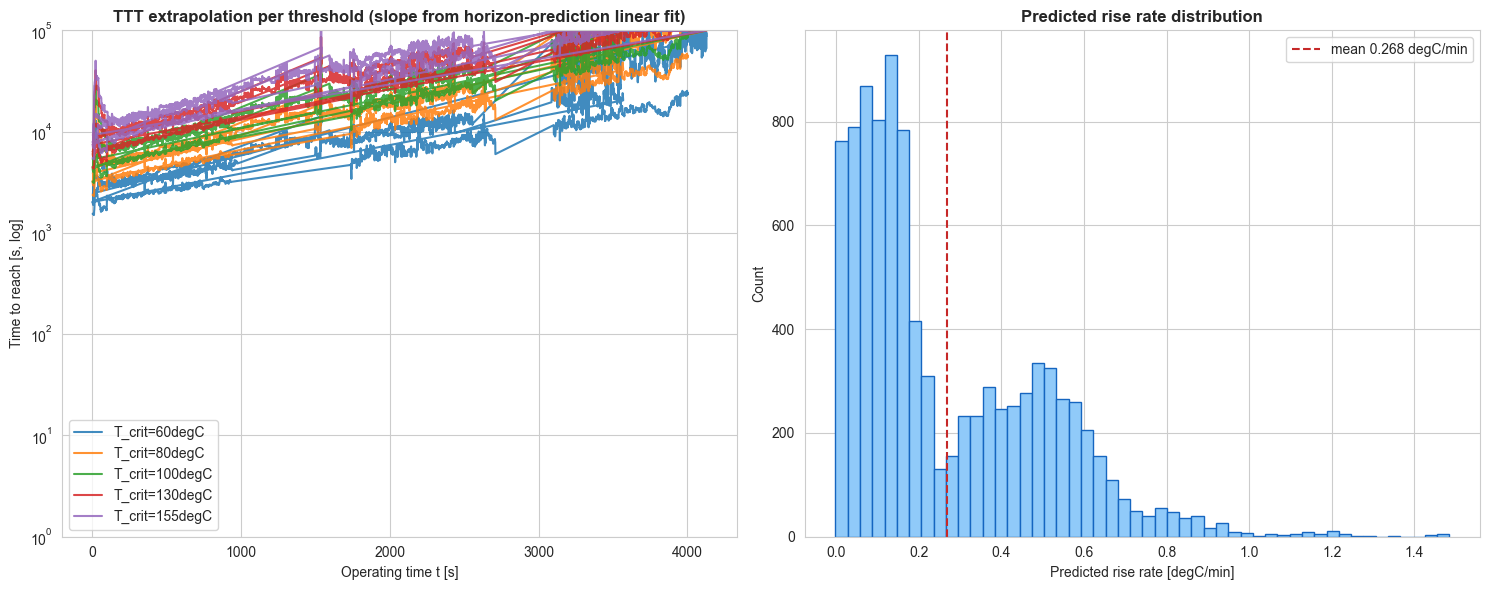

Mean predicted rise rate over last 100s: +0.041 degC/min
  -> essentially steady state. Threshold-crossing scenarios cannot be predicted (extrapolation unstable).

Current core estimates (H=0 prediction), last 5 rows:
  t=3999s  →  T_core_pred = 44.92degC
  t=4000s  →  T_core_pred = 44.92degC
  t=4001s  →  T_core_pred = 44.92degC
  t=4002s  →  T_core_pred = 44.92degC
  t=4003s  →  T_core_pred = 44.92degC

Tip: switch to direct TTT regression once threshold-crossing data is collected.


In [20]:
# ─── 사용자 파라미터 ─────────────────
T_CRIT_LIST = [60, 80, 100, 130, 155]   # degC — 후보 임계값들 (마진 미정 → 여러 개 표시)
USE_MODEL   = BEST_MODEL_NAME             # Section 7에서 자동 선택
# ─────────────────────────────────────

# 다중 호라이즌 예측을 모두 사용해서 시간축 회귀로 외삽 기울기 산출
# 각 시점 t에서 [pred(t+0), pred(t+30), pred(t+60), pred(t+120)] 4점에 직선 적합 → 기울기
import numpy as np

# 모든 호라이즌에 대해 same model로 학습 후 예측
preds_all = {}
for h in HORIZONS:
    mdl = make_models()[USE_MODEL]
    mdl.fit(scaler.transform(X_all), Y_all[h])
    preds_all[h] = mdl.predict(scaler.transform(X_all))

# 각 행마다 4개 호라이즌 예측 → 최소제곱으로 직선 fit (slope = degC/s)
horizons_arr = np.array(HORIZONS)
preds_matrix = np.column_stack([preds_all[h] for h in HORIZONS])  # (N, len(HORIZONS))

# 직선 y = a + b*t  (b = 상승률)
H = horizons_arr - horizons_arr.mean()
denom = (H * H).sum()
slopes = ((preds_matrix - preds_matrix.mean(axis=1, keepdims=True)) * H).sum(axis=1) / denom
T_core_now_pred = preds_all[0]   # H=0 예측 = 현재 코어 추정값

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 좌: 시간에 따른 외삽 TTT (임계값별)
for T_crit in T_CRIT_LIST:
    ttt = np.where(slopes > 1e-4,
                   (T_crit - T_core_now_pred) / slopes,
                   np.inf)
    ttt = np.where(ttt < 0, np.inf, ttt)  # 이미 임계 넘은 경우 무시
    ttt = np.clip(ttt, 0, 1e5)
    axes[0].plot(df["t_sec"], ttt, label=f"T_crit={T_crit}degC", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_ylim(1, 1e5)
axes[0].set_xlabel("Operating time t [s]")
axes[0].set_ylabel("Time to reach [s, log]")
axes[0].set_title("TTT extrapolation per threshold (slope from horizon-prediction linear fit)", fontweight="bold")
axes[0].legend()

# 우: 예측 상승률 분포
axes[1].hist(slopes * 60, bins=50, color=BLUE_LIGHT, edgecolor=BLUE)
axes[1].axvline(slopes.mean()*60, color=RED, linestyle="--",
                label=f"mean {slopes.mean()*60:.3f} degC/min")
axes[1].set_xlabel("Predicted rise rate [degC/min]")
axes[1].set_ylabel("Count")
axes[1].set_title("Predicted rise rate distribution", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_ttt_extrapolation.png", dpi=150, bbox_inches="tight")
plt.show()

last_rate = slopes[-100:].mean() * 60
print(f"Mean predicted rise rate over last 100s: {last_rate:+.3f} degC/min")
if abs(last_rate) < 0.05:
    print("  -> essentially steady state. Threshold-crossing scenarios cannot be predicted (extrapolation unstable).")
print(f"\nCurrent core estimates (H=0 prediction), last 5 rows:")
for i in range(-5, 0):
    print(f"  t={df['t_sec'].iloc[i]:.0f}s  →  T_core_pred = {T_core_now_pred[i]:.2f}degC")
print("\nTip: switch to direct TTT regression once threshold-crossing data is collected.")


## Section 10: Model weight size comparison (ESP32 deployment perspective)

For each candidate model trained on the primary horizon, we record the parameters required for inference and the resulting size (float32 / int8 quantized estimate / joblib pickle).

**What each column means:**
- `params`: weights actually loaded onto ESP32 RAM at inference time
- `float32`: raw C-array size = params × 4 B
- `int8`: post-quantization estimate = params × 1 B (excludes scale/zero-point metadata)
- `pickle`: joblib-saved file size (includes sklearn metadata; larger than deployed footprint)

In [21]:
import joblib

MODELS_DIR = "../output/models"
os.makedirs(MODELS_DIR, exist_ok=True)


def count_inference_params(name, model):
    """Return inference parameters for ESP32 + breakdown string."""
    if name == "Linear":
        n = model.coef_.size + 1
        return n, f"coef({model.coef_.size}) + bias(1)"
    if name.startswith("SVD"):
        pca, lr = model.named_steps["pca"], model.named_steps["lr"]
        n = pca.components_.size + pca.mean_.size + lr.coef_.size + 1
        return n, f"pca_comp({pca.components_.size}) + mean({pca.mean_.size}) + lr_coef({lr.coef_.size}) + bias(1)"
    if name.startswith("Poly"):
        poly, lr = model.named_steps["poly"], model.named_steps["lr"]
        return lr.coef_.size + 1, f"poly_coef({lr.coef_.size}) + bias(1)  [expanded {poly.n_output_features_} terms]"
    if name.startswith("DT"):
        n_nodes = model.tree_.node_count
        return n_nodes * 5, f"{n_nodes} nodes × 5 fields"
    if name.startswith("XGB"):
        df_t = model.get_booster().trees_to_dataframe()
        return len(df_t) * 5, f"{len(df_t)} nodes × 5 fields ({df_t['Tree'].nunique()} trees)"
    return 0, "?"


def fmt_bytes(n):
    if n < 1024:    return f"{n:>7d} B"
    if n < 1024**2: return f"{n/1024:>6.2f} KB"
    return f"{n/1024**2:>6.2f} MB"


# 대표 호라이즌(60s)에 대해 5개 모델 재학습 + 저장 + 측정
size_rows = []
print(f"{'='*100}")
print(f"Weight size comparison (PRIMARY_H = {PRIMARY_H}s, {len(FEATURE_COLS)} features)")
print(f"{'='*100}")
print(f"{'Model':<16} {'MAE':>7} {'R^2':>7} {'#params':>10} "
      f"{'float32':>11} {'int8':>10} {'pickle':>11}  breakdown")
print("-" * 100)

for name, model in make_models().items():
    model.fit(X_train_sc, y_train[PRIMARY_H])
    yp = model.predict(X_test_sc)
    mae = mean_absolute_error(y_test[PRIMARY_H], yp)
    r2  = r2_score(y_test[PRIMARY_H], yp)

    n_params, breakdown = count_inference_params(name, model)
    f32_b, i8_b = n_params * 4, n_params * 1

    fname = name.replace("+","_").replace("(","").replace(")","").replace(",","_").replace(" ","")
    pkl = os.path.join(MODELS_DIR, f"{fname}.pkl")
    joblib.dump(model, pkl, compress=3)
    pkl_b = os.path.getsize(pkl)

    print(f"{name:<16} {mae:>7.4f} {r2:>7.4f} {n_params:>10,d} "
          f"{fmt_bytes(f32_b)} {fmt_bytes(i8_b)} {fmt_bytes(pkl_b)}  {breakdown}")
    size_rows.append({"model": name, "MAE": round(mae,4), "R^2": round(r2,4),
                      "params": n_params, "float32_B": f32_b, "int8_B": i8_b, "pickle_B": pkl_b})

# Scaler도 같이 배포 필요 (입력 정규화 — 또는 LR 계수에 융합 가능)
sc_path = os.path.join(MODELS_DIR, "scaler.pkl")
joblib.dump(scaler, sc_path, compress=3)
sc_params = scaler.mean_.size + scaler.scale_.size
print("-" * 100)
print(f"{'StandardScaler':<16} {'-':>7} {'-':>7} {sc_params:>10,d} "
      f"{fmt_bytes(sc_params*4)} {fmt_bytes(sc_params*1)} {fmt_bytes(os.path.getsize(sc_path))}  "
      f"mean({scaler.mean_.size}) + scale({scaler.scale_.size})")
print("=" * 100)

# 참고: 1D-CNN 분석값
print("[Reference: estimated size of an equivalent 1D-CNN]")
print("  Conv1D(8,k=3) + Dense(16) + Dense(1)  ≈ 200 params  →  float32 800 B / int8 200 B")
print("  Actual .tflite files are ~3-5 KB including header/metadata")

size_df = pd.DataFrame(size_rows).set_index("model")
size_df


Weight size comparison (PRIMARY_H = 0s, 10 features)
Model                MAE     R^2    #params     float32       int8      pickle  breakdown
----------------------------------------------------------------------------------------------------
Linear            0.1802  0.9973         11      44 B      11 B     624 B  coef(10) + bias(1)
SVD(6)+LR         1.3926  0.9043         77     308 B      77 B   1.58 KB  pca_comp(60) + mean(10) + lr_coef(6) + bias(1)
Poly(2)+LR        0.0786  0.9994         66     264 B      66 B   1.67 KB  poly_coef(65) + bias(1)  [expanded 65 terms]
DT(d=5)           0.2089  0.9972        315   1.23 KB     315 B   2.51 KB  63 nodes × 5 fields
XGB               0.0442  0.9999     30,390 118.71 KB  29.68 KB  69.50 KB  6078 nodes × 5 fields (200 trees)
----------------------------------------------------------------------------------------------------
StandardScaler         -       -         20      80 B      20 B     689 B  mean(10) + scale(10)
[Reference: estimat

,MAE,R^2,params,float32_B,int8_B,pickle_B
model,,,,,,
Linear,0.1802,0.9973,11,44,11,624
SVD(6)+LR,1.3926,0.9043,77,308,77,1617
Poly(2)+LR,0.0786,0.9994,66,264,66,1708
DT(d=5),0.2089,0.9972,315,1260,315,2567
XGB,0.0442,0.9999,30390,121560,30390,71165


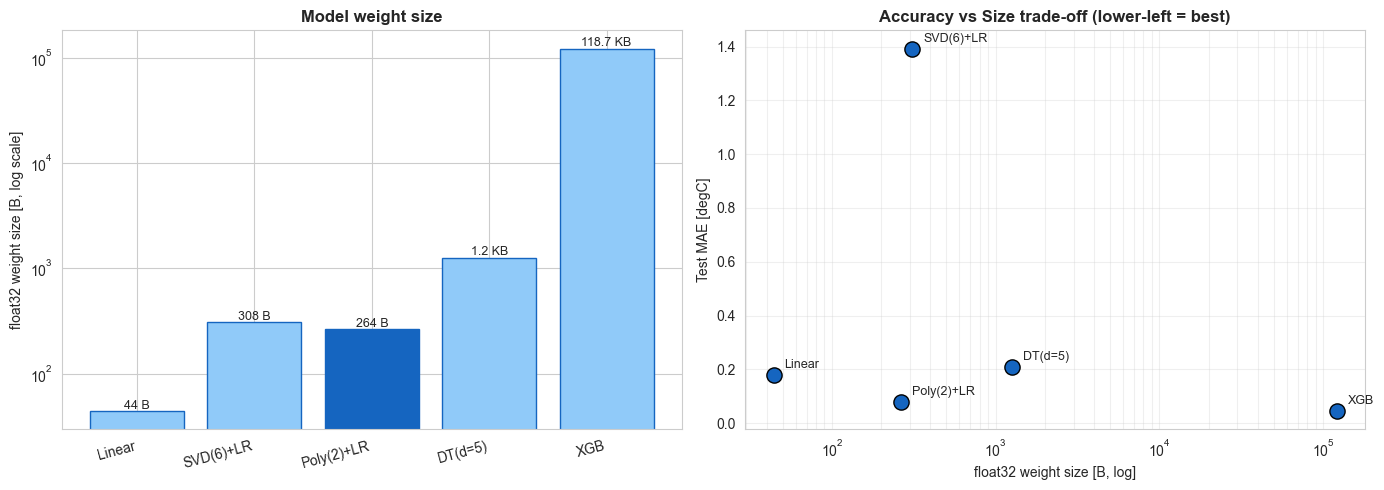

Lower-left (small + accurate) = best for ESP32.


In [22]:
# 시각화: 정확도(MAE) vs 크기(float32 B) 트레이드오프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: bar — 모델별 float32 가중치 크기 (log scale)
ax = axes[0]
colors = [BLUE_LIGHT if m != "Poly(2)+LR" else BLUE for m in size_df.index]
bars = ax.bar(size_df.index, size_df["float32_B"], color=colors, edgecolor=BLUE)
for b, v in zip(bars, size_df["float32_B"]):
    label = f"{v} B" if v < 1024 else f"{v/1024:.1f} KB"
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.05, label, ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("float32 weight size [B, log scale]")
ax.set_title("Model weight size", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# 우: scatter — MAE vs 크기 (Pareto 시각화)
ax = axes[1]
ax.scatter(size_df["float32_B"], size_df["MAE"], s=120, color=BLUE, edgecolor="black", zorder=3)
for name, row in size_df.iterrows():
    ax.annotate(name, (row["float32_B"], row["MAE"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("float32 weight size [B, log]")
ax.set_ylabel("Test MAE [degC]")
ax.set_title("Accuracy vs Size trade-off (lower-left = best)", fontweight="bold")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/11_model_size_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Lower-left (small + accurate) = best for ESP32.")


## Section 11: Feature-set ablation study

Compare three feature configurations on the **same merged dataset** (already vibration-aligned in Section 1):

| Set | Description | # features |
|---|---|---|
| baseline | thermistor only | 7 |
| pruned   | EDA-selected (Section 2.5) | len(FEATURE_COLS) |
| full     | all 21 candidates | 21 |

This isolates the value of vibration features under fair comparison.

In [23]:
# Ablation: baseline (thermistor 7) vs pruned (EDA) vs full (21)
SETS = {
    "baseline (thermistor 7)": THERM_FEATURES,
    f"pruned ({len(FEATURE_COLS)})": FEATURE_COLS,
    f"full (21)": ALL_CANDIDATES,
}

idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)
y = df[PRIMARY_TARGET].values

abl_rows = []
for set_name, feats in SETS.items():
    X = df[feats].values
    Xtr, Xte = X[idx_tr], X[idx_te]
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

    for mname, m in [("Linear", LinearRegression()),
                     ("Poly(2)+LR", Pipeline([("poly", PolynomialFeatures(2, include_bias=False)),
                                              ("lr",   LinearRegression())])),
                     ("XGB", XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                          random_state=42, verbosity=0))]:
        m.fit(Xtr_s, y[idx_tr])
        yp = m.predict(Xte_s)
        n = len(feats)
        poly_terms = n + n + n*(n-1)//2 + 1
        abl_rows.append({
            "set": set_name,
            "model": mname,
            "n_feats": n,
            "MAE": mean_absolute_error(y[idx_te], yp),
            "R^2":  r2_score(y[idx_te], yp),
            "Poly2 size (B)": poly_terms*4 if mname == "Poly(2)+LR" else None,
        })

abl_df = pd.DataFrame(abl_rows)
print("=== Feature-set ablation on PRIMARY_TARGET={} ===".format(PRIMARY_TARGET))
print(abl_df.to_string(index=False))


=== Feature-set ablation on PRIMARY_TARGET=core_t0 ===
                    set      model  n_feats      MAE      R^2  Poly2 size (B)
baseline (thermistor 7)     Linear        7 0.185302 0.996981             NaN
baseline (thermistor 7) Poly(2)+LR        7 0.108217 0.998899           144.0
baseline (thermistor 7)        XGB        7 0.038419 0.999884             NaN
            pruned (10)     Linear       10 0.180180 0.997343             NaN
            pruned (10) Poly(2)+LR       10 0.078591 0.999366           264.0
            pruned (10)        XGB       10 0.044232 0.999860             NaN
              full (21)     Linear       21 0.126666 0.998604             NaN
              full (21) Poly(2)+LR       21 0.077716 0.997963          1012.0
              full (21)        XGB       21 0.038150 0.999889             NaN


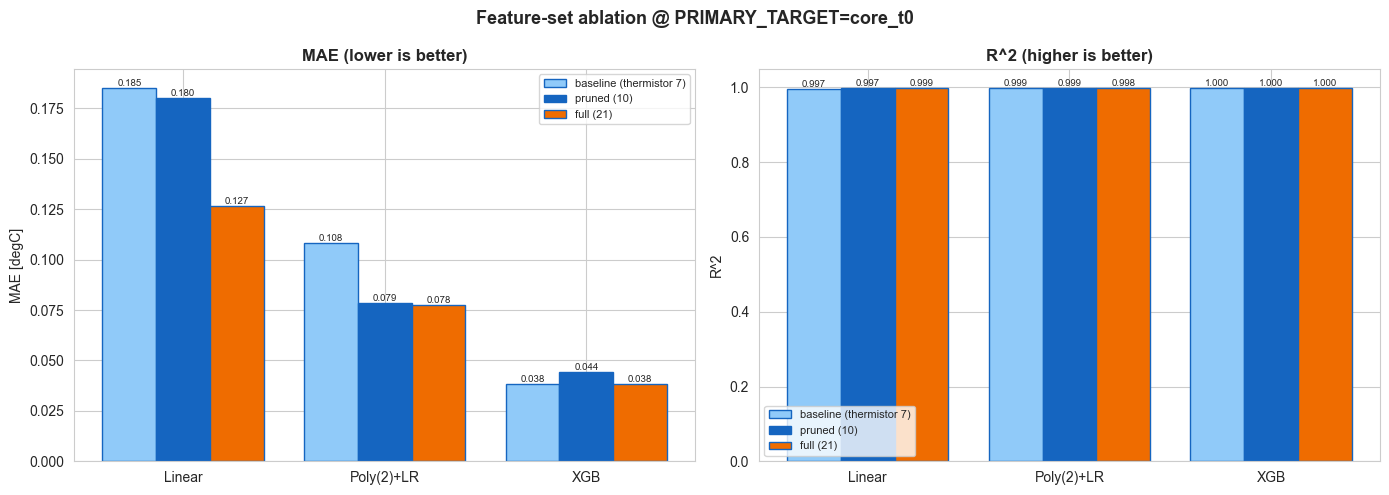

In [24]:
# Ablation visualization — MAE and R^2 across feature sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_x = ["Linear", "Poly(2)+LR", "XGB"]
sets_x = list(SETS.keys())
n_sets = len(sets_x)
w = 0.8 / n_sets
colors = [BLUE_LIGHT, BLUE, ORANGE]

for ax, metric, ylabel, lower_better in [
    (axes[0], "MAE", "MAE [degC]", True),
    (axes[1], "R^2", "R^2",        False),
]:
    for i, set_name in enumerate(sets_x):
        vals = [abl_df[(abl_df["set"]==set_name) & (abl_df["model"]==m)][metric].values[0]
                for m in models_x]
        x = np.arange(len(models_x)) + (i - n_sets/2 + 0.5) * w
        ax.bar(x, vals, width=w, color=colors[i % len(colors)], edgecolor=BLUE, label=set_name)
        for xx, v in zip(x, vals):
            ax.text(xx, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(np.arange(len(models_x)))
    ax.set_xticklabels(models_x)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{metric} ({'lower is better' if lower_better else 'higher is better'})",
                 fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle(f"Feature-set ablation @ PRIMARY_TARGET={PRIMARY_TARGET}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/13_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
